# Creating Numbers/images with AI: A Hands-on Diffusion Model Exercise

## Introduction
In this assignment, you'll learn how to create an AI model that can generate realistic images from scratch using a powerful technique called 'diffusion'. Think of it like teaching AI to draw by first learning how images get blurry and then learning to make them clear again.

### What We'll Build
- A diffusion model capable of generating realistic images
- For most students: An AI that generates handwritten digits (0-9) using the MNIST dataset
- For students with more computational resources: Options to work with more complex datasets
- Visual demonstrations of how random noise gradually transforms into clear, recognizable images
- By the end, your AI should create images realistic enough for another AI to recognize them

### Dataset Options
This lab offers flexibility based on your available computational resources:

- Standard Option (Free Colab): We'll primarily use the MNIST handwritten digit dataset, which works well with limited GPU memory and completes training in a reasonable time frame. Most examples and code in this notebook are optimized for MNIST.

- Advanced Option: If you have access to more powerful GPUs (either through Colab Pro/Pro+ or your own hardware), you can experiment with more complex datasets like Fashion-MNIST, CIFAR-10, or even face generation. You'll need to adapt the model architecture, hyperparameters, and evaluation metrics accordingly.

### Resource Requirements
- Basic MNIST: Works with free Colab GPUs (2-4GB VRAM), ~30 minutes training
- Fashion-MNIST: Similar requirements to MNIST
CIFAR-10: Requires more memory (8-12GB VRAM) and longer training (~2 hours)
- Higher resolution images: Requires substantial GPU resources and several hours of training

### Before You Start
1. Make sure you're running this in Google Colab or another environment with GPU access
2. Go to 'Runtime' → 'Change runtime type' and select 'GPU' as your hardware accelerator
3. Each code cell has comments explaining what it does
4. Don't worry if you don't understand every detail - focus on the big picture!
5. If working with larger datasets, monitor your GPU memory usage carefully

The concepts you learn with MNIST will scale to more complex datasets, so even if you're using the basic option, you'll gain valuable knowledge about generative AI that applies to more advanced applications.



## Step 1: Setting Up Our Tools
First, let's install and import all the tools we need. Run this cell and wait for it to complete.

In [1]:
# Step 1: Install required packages
%pip install einops
print("Package installation complete.")

# Step 2: Import libraries
# --- Core PyTorch libraries ---
import torch  # Main deep learning framework
import torch.nn.functional as F  # Neural network functions like activation functions
import torch.nn as nn  # Neural network building blocks (layers)
from torch.optim import Adam  # Optimization algorithm for training

# --- Data handling ---
from torch.utils.data import Dataset, DataLoader  # For organizing and loading our data
import torchvision  # Library for computer vision datasets and models
import torchvision.transforms as transforms  # For preprocessing images

# --- Tensor manipulation ---
import random  # For random operations
from einops.layers.torch import Rearrange  # For reshaping tensors in neural networks
from einops import rearrange  # For elegant tensor reshaping operations
import numpy as np  # For numerical operations on arrays

# --- System utilities ---
import os  # For operating system interactions (used for CPU count)

# --- Visualization tools ---
import matplotlib.pyplot as plt  # For plotting images and graphs
from PIL import Image  # For image processing
from torchvision.utils import save_image, make_grid  # For saving and displaying image grids

# Step 3: Set up device (GPU or CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"We'll be using: {device}")

# Check if we're actually using GPU (for students to verify)
if device.type == "cuda":
    print(f"GPU name: {torch.cuda.get_device_name(0)}")
    print(f"GPU memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
else:
    print("Note: Training will be much slower on CPU. Consider using Google Colab with GPU enabled.")

Package installation complete.
We'll be using: cpu
Note: Training will be much slower on CPU. Consider using Google Colab with GPU enabled.



###  REPRODUCIBILITY AND DEVICE SETUP

In [2]:
# Step 4: Set random seeds for reproducibility
# Diffusion models are sensitive to initialization, so reproducible results help with debugging
SEED = 42  # Universal seed value for reproducibility
torch.manual_seed(SEED)          # PyTorch random number generator
np.random.seed(SEED)             # NumPy random number generator
random.seed(SEED)                # Python's built-in random number generator

print(f"Random seeds set to {SEED} for reproducible results")

# Configure CUDA for GPU operations if available
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)       # GPU random number generator
    torch.cuda.manual_seed_all(SEED)   # All GPUs random number generator

    # Ensure deterministic GPU operations
    # Note: This slightly reduces performance but ensures results are reproducible
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    try:
        # Check available GPU memory
        gpu_memory = torch.cuda.get_device_properties(0).total_memory / 1e9  # Convert to GB
        print(f"Available GPU Memory: {gpu_memory:.1f} GB")

        # Add recommendation based on memory
        if gpu_memory < 4:
            print("Warning: Low GPU memory. Consider reducing batch size if you encounter OOM errors.")
    except Exception as e:
        print(f"Could not check GPU memory: {e}")
else:
    print("No GPU detected. Training will be much slower on CPU.")
    print("If you're using Colab, go to Runtime > Change runtime type and select GPU.")

Random seeds set to 42 for reproducible results
No GPU detected. Training will be much slower on CPU.
If you're using Colab, go to Runtime > Change runtime type and select GPU.


## Step 2: Choosing Your Dataset

You have several options for this exercise, depending on your computer's capabilities:

### Option 1: MNIST (Basic - Works on Free Colab)
- Content: Handwritten digits (0-9)
- Image size: 28x28 pixels, Grayscale
- Training samples: 60,000
- Memory needed: ~2GB GPU
- Training time: ~15-30 minutes on Colab
- **Choose this if**: You're using free Colab or have a basic GPU

### Option 2: Fashion-MNIST (Intermediate)
- Content: Clothing items (shirts, shoes, etc.)
- Image size: 28x28 pixels, Grayscale
- Training samples: 60,000
- Memory needed: ~2GB GPU
- Training time: ~15-30 minutes on Colab
- **Choose this if**: You want more interesting images but have limited GPU

### Option 3: CIFAR-10 (Advanced)
- Content: Real-world objects (cars, animals, etc.)
- Image size: 32x32 pixels, Color (RGB)
- Training samples: 50,000
- Memory needed: ~4GB GPU
- Training time: ~1-2 hours on Colab
- **Choose this if**: You have Colab Pro or a good local GPU (8GB+ memory)

### Option 4: CelebA (Expert)
- Content: Celebrity face images
- Image size: 64x64 pixels, Color (RGB)
- Training samples: 200,000
- Memory needed: ~8GB GPU
- Training time: ~3-4 hours on Colab
- **Choose this if**: You have excellent GPU (12GB+ memory)

To use your chosen dataset, uncomment its section in the code below and make sure all others are commented out.

In [3]:
#===============================================================================
# SECTION 2: DATASET SELECTION AND CONFIGURATION
#===============================================================================
# OPTION 1: MNIST (Basic - 2GB GPU)
#-------------------------------------------

IMG_SIZE = 28
IMG_CH = 1
N_CLASSES = 10
BATCH_SIZE = 64
EPOCHS = 30

# Transformation: convert to tensor and normalize between [-1, 1]
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Load MNIST training dataset
from torchvision import datasets

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    transform=transform,
    download=True
)

# Create dataloader
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

# Print confirmation and dataset info
print(f"✅ MNIST dataset loaded successfully!")
print(f"Total training samples: {len(train_dataset)}")
print(f"Image size: {IMG_SIZE}x{IMG_SIZE} | Channels: {IMG_CH} | Classes: {N_CLASSES}")
print(f"Batch size: {BATCH_SIZE} | Epochs: {EPOCHS}")


100%|██████████| 9.91M/9.91M [00:00<00:00, 19.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 501kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.60MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.65MB/s]

✅ MNIST dataset loaded successfully!
Total training samples: 60000
Image size: 28x28 | Channels: 1 | Classes: 10
Batch size: 64 | Epochs: 30


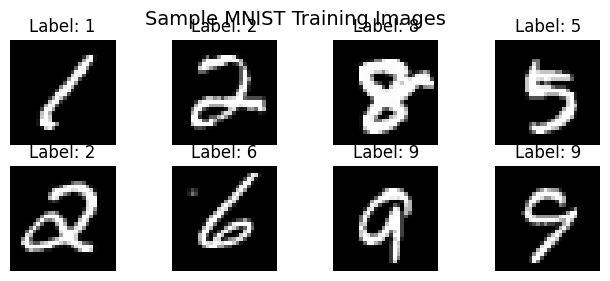

In [4]:
# Quick visualization of MNIST samples
import matplotlib.pyplot as plt

examples = next(iter(train_loader))
images, labels = examples

plt.figure(figsize=(8, 3))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(images[i][0], cmap="gray")
    plt.title(f"Label: {labels[i].item()}")
    plt.axis("off")
plt.suptitle("Sample MNIST Training Images", fontsize=14)
plt.show()


In [5]:
#===============================================================================
# VALIDATING DATASET SELECTION AND GPU MEMORY
#===============================================================================

# Validate dataset selection
if 'train_dataset' not in locals():
    raise ValueError("""
    ❌ ERROR: No dataset selected! Please uncomment exactly one dataset option.
    Available options:
    1. MNIST (Basic) - 2GB GPU
    2. Fashion-MNIST (Intermediate) - 2GB GPU
    3. CIFAR-10 (Advanced) - 4GB+ GPU
    4. CelebA (Expert) - 8GB+ GPU
    """)

print("✅ Dataset successfully validated!")

# Validate GPU memory availability
import torch

if torch.cuda.is_available():
    gpu_props = torch.cuda.get_device_properties(0)
    gpu_name = gpu_props.name
    gpu_memory_gb = gpu_props.total_memory / 1e9

    print(f"🧠 GPU detected: {gpu_name}")
    print(f"💾 Total GPU memory: {gpu_memory_gb:.2f} GB")

    # Check if the GPU meets dataset requirements
    if gpu_memory_gb < 2:
        print("⚠️ Warning: Very low GPU memory (<2GB). MNIST should work, but training may be slow.")
    elif gpu_memory_gb < 4:
        print("✅ GPU suitable for MNIST or Fashion-MNIST.")
    elif gpu_memory_gb < 8:
        print("✅ GPU can handle CIFAR-10 comfortably.")
    else:
        print("🚀 Excellent GPU — capable of running all datasets including CelebA.")
else:
    print("❌ No GPU detected! Running on CPU — training will be significantly slower.")
    print("💡 Tip: In Colab, go to Runtime → Change runtime type → GPU.")


✅ Dataset successfully validated!
❌ No GPU detected! Running on CPU — training will be significantly slower.
💡 Tip: In Colab, go to Runtime → Change runtime type → GPU.


In [7]:
#===============================================================================
# DATASET PROPERTIES AND SAMPLE BATCH CHECK
#===============================================================================
from torch.utils.data import DataLoader
import torch, os

# Temporary data loader for inspection
sample_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
images, labels = next(iter(sample_loader))

print("✅ Sample batch successfully retrieved!")
print(f"- Images shape : {images.shape}   (B, C, H, W)")
print(f"- Data type    : {images.dtype}")
print(f"- Device       : {images.device}")
print(f"- Value range  : min={images.min().item():.3f}, max={images.max().item():.3f}")
print(f"- Labels shape : {labels.shape}")
print(f"- Labels dtype : {labels.dtype}")
print(f"- Unique labels in batch: {sorted(labels.unique().tolist())}")

# Optional: verify normalization around [-1, 1] for MNIST/FashionMNIST
if images.min() >= -1.5 and images.max() <= 1.5:
    print("🔎 Note: Images seem properly normalized (≈ [-1, 1]).")


✅ Sample batch successfully retrieved!
- Images shape : torch.Size([16, 1, 28, 28])   (B, C, H, W)
- Data type    : torch.float32
- Device       : cpu
- Value range  : min=-1.000, max=1.000
- Labels shape : torch.Size([16])
- Labels dtype : torch.int64
- Unique labels in batch: [1, 2, 3, 4, 6, 7, 8, 9]
🔎 Note: Images seem properly normalized (≈ [-1, 1]).


In [8]:
#===============================================================================
# SECTION 3: DATASET SPLITTING AND DATALOADER CONFIGURATION
#===============================================================================
from torch.utils.data import random_split

dataset_len = len(train_dataset)
train_len   = int(0.8 * dataset_len)
val_len     = dataset_len - train_len

# Ensure reproducibility
g = torch.Generator().manual_seed(42)

train_subset, val_subset = random_split(train_dataset, [train_len, val_len], generator=g)

print("✅ Train/Validation split created successfully!")
print(f"- Total samples : {dataset_len}")
print(f"- Train samples : {len(train_subset)}")
print(f"- Validation samples : {len(val_subset)}")


✅ Train/Validation split created successfully!
- Total samples : 60000
- Train samples : 48000
- Validation samples : 12000


In [9]:
from torch.utils.data import DataLoader
import math

# Configure workers and memory settings
num_workers = max(0, min(4, (os.cpu_count() or 0)))  # Safe & portable
pin = torch.cuda.is_available()

train_loader = DataLoader(
    train_subset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=num_workers, pin_memory=pin, drop_last=True
)
val_loader = DataLoader(
    val_subset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=num_workers, pin_memory=pin, drop_last=False
)

print("✅ Data loaders successfully configured!")
print(f"- Batch size     : {BATCH_SIZE}")
print(f"- Num workers    : {num_workers}")
print(f"- Pin memory     : {pin}")
print(f"- Train batches  : {math.ceil(len(train_subset)/BATCH_SIZE)}")
print(f"- Val batches    : {math.ceil(len(val_subset)/BATCH_SIZE)}")


✅ Data loaders successfully configured!
- Batch size     : 64
- Num workers    : 2
- Pin memory     : False
- Train batches  : 750
- Val batches    : 188


## Step 3: Building Our Model Components

Now we'll create the building blocks of our AI model. Think of these like LEGO pieces that we'll put together to make our number generator:

- GELUConvBlock: The basic building block that processes images
- DownBlock: Makes images smaller while finding important features
- UpBlock: Makes images bigger again while keeping the important features
- Other blocks: Help the model understand time and what number to generate

In [105]:
# =========================
# ---- FIX PACK (DROP-IN)
# Put this cell AFTER Step 3 blocks and BEFORE training / sampling
# =========================

import torch
import torch.nn as nn
import torch.nn.functional as F
from einops.layers.torch import Rearrange

# ---------- Safe RearrangePoolBlock (auto-pad if H/W are odd) ----------
class RearrangePoolBlock(nn.Module):
    """
    Space-to-depth downsample (×2) con autopadding para alturas/anchos impares.
    Entrada:  [B, C, H, W]
    Salida:   [B, 2C, H/2, W/2]
    """
    def __init__(self, in_chs: int, group_size: int = 8):
        super().__init__()
        mid_chs = in_chs * 4          # tras space-to-depth
        out_chs = in_chs * 2          # típico widening al bajar resolución
        self.space_to_depth = Rearrange('b c (h p1) (w p2) -> b (c p1 p2) h w', p1=2, p2=2)
        self.conv = GELUConvBlock(mid_chs, out_chs, group_size)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        h, w = x.shape[-2:]
        pad_h = h % 2
        pad_w = w % 2
        if pad_h or pad_w:
            # pad=(left, right, top, bottom)
            x = F.pad(x, (0, pad_w, 0, pad_h), mode='reflect')
        x = self.space_to_depth(x)    # (B, C*4, H/2, W/2)
        x = self.conv(x)
        return x

# ---------- DownBlock (usa el RearrangePoolBlock seguro) ----------
class DownBlock(nn.Module):
    def __init__(self, in_chs: int, out_chs: int, group_size: int = 8):
        super().__init__()
        self.conv = GELUConvBlock(in_chs, out_chs, group_size)
        self.pool = RearrangePoolBlock(out_chs, group_size)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.conv(x)
        # (RearrangePoolBlock ya autopadilla si hace falta)
        x = self.pool(x)
        return x

# ---------- UpBlock (alinea tamaños antes de concatenar) ----------
class UpBlock(nn.Module):
    """
    Upsample (×2) + concat skip + dos conv blocks. Alinea H/W con padding si difiere ±1 px.
    """
    def __init__(self, in_chs: int, skip_chs: int, out_chs: int, group_size: int = 8):
        super().__init__()
        self.upsample = nn.Sequential(
            nn.Upsample(scale_factor=2, mode="nearest"),
            nn.Conv2d(in_chs, in_chs, kernel_size=1, bias=False),
        )
        self.fuse = nn.Sequential(
            GELUConvBlock(in_chs + skip_chs, out_chs, group_size),
            GELUConvBlock(out_chs, out_chs, group_size),
        )

    def forward(self, x, skip):
        x = self.upsample(x)
        # Alinear espacialmente con el skip (puede diferir por 1 px)
        if x.shape[-2:] != skip.shape[-2:]:
            H = min(x.shape[-2], skip.shape[-2])
            W = min(x.shape[-1], skip.shape[-1])
            x    = x[...,    :H, :W]
            skip = skip[..., :H, :W]
        x = torch.cat([x, skip], dim=1)
        return self.fuse(x)

# ---------- UNet (re-instanciado con los bloques seguros) ----------
class UNet(nn.Module):
    def __init__(self, T, img_ch, img_size, down_chs, t_embed_dim, c_embed_dim,
                 n_classes: int = N_CLASSES, group_size: int = 8):
        super().__init__()
        self.img_ch   = img_ch
        self.img_size = img_size
        self.down_chs = down_chs

        # time embedding
        self.t_sinus = SinusoidalPositionEmbedBlock(t_embed_dim)
        self.t_mlp   = nn.Sequential(
            nn.Linear(t_embed_dim, t_embed_dim), nn.GELU(),
            nn.Linear(t_embed_dim, t_embed_dim), nn.GELU(),
        )

        # class embedding
        self.c_embed = EmbedBlock(input_dim=n_classes, emb_dim=c_embed_dim)

        # stem
        self.stem = GELUConvBlock(img_ch, down_chs[0], group_size)

        # encoder
        self.down = nn.ModuleList()
        self.skip_channels = []
        in_ch = down_chs[0]
        for out_ch in down_chs:
            self.down.append(DownBlock(in_ch, out_ch, group_size))
            self.skip_channels.append(out_ch)
            in_ch = out_ch * 2  # tras RearrangePool: canales duplican

        # bottleneck
        bottleneck_ch = in_ch
        self.mid = nn.Sequential(
            GELUConvBlock(bottleneck_ch, bottleneck_ch, group_size),
            GELUConvBlock(bottleneck_ch, bottleneck_ch, group_size),
        )
        self.t_proj = nn.Linear(t_embed_dim, bottleneck_ch)
        self.c_proj = nn.Linear(c_embed_dim, bottleneck_ch)

        # decoder
        self.up = nn.ModuleList()
        cur = bottleneck_ch
        for skip_ch in reversed(self.skip_channels):
            self.up.append(UpBlock(in_chs=cur, skip_chs=skip_ch, out_chs=skip_ch, group_size=group_size))
            cur = skip_ch

        # head
        self.head = nn.Conv2d(cur, img_ch, kernel_size=1)

    def forward(self, x, t, c, c_mask):
        # embeddings
        t_emb = self.t_mlp(self.t_sinus(t))                    # [B, t_dim]
        # c puede ser indices o one-hot; EmbedBlock maneja ambos
        c_emb = self.c_embed(c).view(c.shape[0], -1)           # [B, c_dim]

        # stem
        h = self.stem(x)

        # encoder (guardamos skips ANTES de bajar)
        skips = []
        for block, skip_ch in zip(self.down, self.skip_channels):
            skips.append(h)          # mismo tamaño que 'skip_ch' por diseño
            h = block(h)

        # bottleneck + condicionamiento (broadcast)
        h = self.mid(h)
        t_feat = self.t_proj(t_emb).unsqueeze(-1).unsqueeze(-1)   # [B, C,1,1]
        c_feat = self.c_proj(c_emb).unsqueeze(-1).unsqueeze(-1)   # [B, C,1,1]
        h = h + t_feat + c_feat * c_mask                          # c_mask: [B,1]

        # decoder
        for up, skip in zip(self.up, reversed(skips)):
            h = up(h, skip)

        return self.head(h)

# ---------- Re-instanciar el modelo con los bloques seguros ----------
model = UNet(
    T=n_steps,
    img_ch=IMG_CH,
    img_size=IMG_SIZE,
    down_chs=(32, 64),      # (puedes cambiar como antes)
    t_embed_dim=8,
    c_embed_dim=N_CLASSES
).to(device)

print("✅ UNet reinstanciado con bloques seguros (autopad + upsample alineado).")

# ---------- remove_noise: sin cambio funcional, pero robusto ----------
@torch.no_grad()
def remove_noise(x_t, t, model, c, c_mask):
    t = t.long().clamp_(0, n_steps - 1).to(x_t.device)
    predicted_noise = model(x_t, t, c, c_mask)

    alpha_t     = alpha[t].view(-1,1,1,1).to(x_t.device)
    beta_t      = beta[t].view(-1,1,1,1).to(x_t.device)
    alpha_bar_t = alpha_bar[t].view(-1,1,1,1).to(x_t.device)
    sqrt_one_minus_alpha_bar_t = torch.sqrt(1.0 - alpha_bar_t)

    mean = (1.0 / torch.sqrt(alpha_t)) * (
        x_t - (beta_t / sqrt_one_minus_alpha_bar_t) * predicted_noise
    )

    if torch.all(t == 0):
        return mean
    noise = torch.randn_like(x_t)
    return mean + torch.sqrt(beta_t) * noise

# ---------- Helpers de muestreo con c_mask correcto ----------
@torch.no_grad()
def generate_samples(model, n_samples=8, label=None):
    model.eval()
    if label is None:
        c = torch.randint(0, N_CLASSES, (n_samples,), device=device)
    else:
        c = torch.full((n_samples,), int(label), device=device)
    c_one_hot = F.one_hot(c, N_CLASSES).float()
    c_mask = torch.ones((n_samples, 1), device=device)  # <- forma correcta

    x = torch.randn(n_samples, IMG_CH, IMG_SIZE, IMG_SIZE, device=device)
    for t in range(n_steps - 1, -1, -1):
        t_batch = torch.full((n_samples,), t, device=device)
        x = remove_noise(x, t_batch, model, c_one_hot, c_mask)

    grid = make_grid(x, nrow=max(2, n_samples // 2), normalize=True, value_range=(-1, 1))
    plt.figure(figsize=(6, 6))
    if IMG_CH == 1: plt.imshow(grid[0].cpu(), cmap='gray')
    else:           plt.imshow(grid.permute(1, 2, 0).cpu())
    plt.axis('off'); plt.title('Generated Samples'); plt.show()

@torch.no_grad()
def visualize_generation_steps(model, number, n_preview_steps=10):
    model.eval()
    x = torch.randn(1, IMG_CH, IMG_SIZE, IMG_SIZE, device=device)

    c = torch.tensor([number], device=device)
    c_one_hot = F.one_hot(c, N_CLASSES).float()
    c_mask = torch.ones((c.shape[0], 1), device=device)   # <- forma correcta

    steps_to_show = torch.linspace(n_steps-1, 0, n_preview_steps).long().tolist()
    images = [x[0].cpu()]

    for t in range(n_steps-1, -1, -1):
        t_batch = torch.full((1,), t, device=device)
        x = remove_noise(x, t_batch, model, c_one_hot, c_mask)
        if t in steps_to_show:
            images.append(x[0].detach().cpu())

    plt.figure(figsize=(2.2*len(images), 3))
    for i, img in enumerate(images):
        plt.subplot(1, len(images), i+1)
        if IMG_CH == 1:
            plt.imshow(img[0], cmap='gray')
        else:
            im = img.permute(1, 2, 0)
            if im.min() < 0: im = (im + 1) / 2
            plt.imshow(im)
        plt.title('noise' if i == 0 else f"t={steps_to_show[i-1]}")
        plt.axis('off')
    plt.tight_layout(); plt.show()


✅ UNet reinstanciado con bloques seguros (autopad + upsample alineado).


In [10]:
# ============================================
# GELUConvBlock: Conv -> GroupNorm -> GELU (x2)
# ============================================
class GELUConvBlock(nn.Module):
    def __init__(self, in_ch: int, out_ch: int, group_size: int = 8):
        """
        Convolutional block with GroupNorm and GELU activations (two conv layers).

        Args:
            in_ch (int):  Number of input channels
            out_ch (int): Number of output channels
            group_size (int): Desired number of groups for GroupNorm
        """
        super().__init__()

        # Ensure group_size divides out_ch (required by GroupNorm)
        g = min(group_size, out_ch)
        while out_ch % g != 0 and g > 1:
            g -= 1
        if out_ch % g != 0:  # fallback to LayerNorm-like behavior (g=1) if needed
            g = 1

        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.GroupNorm(num_groups=g, num_channels=out_ch),
            nn.GELU(),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.GroupNorm(num_groups=g, num_channels=out_ch),
            nn.GELU(),
        )

    def forward(self, x):
        return self.block(x)


In [82]:
# ============================================================
# RearrangePoolBlock: Space-to-Depth (×4 channels) + GELUConvBlock
# Downsamples spatial dims by 2× using pixel-unshuffle via einops
# ============================================================
class RearrangePoolBlock(nn.Module):
    def __init__(self, in_chs: int, group_size: int = 8):
        """
        Downsample by rearranging pixels (space-to-depth) and process with a conv block.

        Args:
            in_chs (int):   Number of input channels
            group_size (int): Number of groups for GroupNorm inside GELUConvBlock
        """
        super().__init__()
        # After space-to-depth with factor 2: channels become in_chs * 4
        mid_chs = in_chs * 4
        out_chs = in_chs * 2  # typical choice: increase channels while downsampling

        self.space_to_depth = Rearrange(
            'b c (h p1) (w p2) -> b (c p1 p2) h w',
            p1=2, p2=2
        )
        self.conv = GELUConvBlock(mid_chs, out_chs, group_size)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Ensure H and W are divisible by 2 before space-to-depth
        h, w = x.shape[-2:]
        pad_h = (2 - (h % 2)) % 2 # Calculate padding needed to make h even
        pad_w = (2 - (w % 2)) % 2 # Calculate padding needed to make w even

        if pad_h > 0 or pad_w > 0:
            x = F.pad(x, (0, pad_w, 0, pad_h), mode='replicate')

        # Now H and W are guaranteed to be divisible by 2
        x = self.space_to_depth(x)  # (B, C*4, H/2, W/2)
        x = self.conv(x)
        return x

In [44]:
class UpBlock(nn.Module):
    """
    Upsampling block for decoding path in U-Net.

    Steps:
      1) Upsample spatial dims by 2x
      2) Concatenate skip features from encoder
      3) Fuse with two GELUConvBlocks

    Args:
        in_chs (int): channels of the tensor coming from the lower level
        skip_chs (int): channels of the corresponding skip connection
        out_chs (int): output channels after fusion
        group_size (int): GroupNorm groups inside conv blocks
    """
    def __init__(self, in_chs, skip_chs, out_chs, group_size=8, mode="nearest"):
        super().__init__()
        # 2× upsample + light conv to reduce checkerboard artifacts
        self.upsample = nn.Sequential(
            nn.Upsample(scale_factor=2, mode=mode),
            nn.Conv2d(in_chs, in_chs, kernel_size=1, bias=False)
        )
        # After concat, channels = in_chs + skip_chs
        fused_in = in_chs + skip_chs
        self.fuse = nn.Sequential(
            GELUConvBlock(fused_in, out_chs, group_size),
            GELUConvBlock(out_chs, out_chs, group_size),
        )

    def forward(self, x, skip):
        """
        x:    [B, in_chs,  H,  W]   (lower-resolution input)
        skip: [B, skip_chs, H*2, W*2] (encoder feature to concatenate)
        -> returns [B, out_chs, H*2, W*2]
        """
        x = self.upsample(x)
        # Ensure spatial sizes match (some datasets can be odd-sized)
        if x.shape[-2:] != skip.shape[-2:]:
            # Safe crop/resize to match skip
            H = min(x.shape[-2], skip.shape[-2])
            W = min(x.shape[-1], skip.shape[-1])
            x = x[..., :H, :W]
            skip = skip[..., :H, :W]
        x = torch.cat([x, skip], dim=1)
        return self.fuse(x)

In [13]:
# Now let's implement the upsampling block for our U-Net architecture:
class UpBlock(nn.Module):
    """
    Upsampling block for decoding path in U-Net architecture.

    This block:
      1) Concatenates 'x' (decoder) with the matching 'skip' (encoder)
      2) Upsamples spatial dims by 2× via transposed conv
      3) Refines with two GELUConvBlocks

    NOTE: We pass 'in_chs' here as the **CONCATENATED** channels (x + skip).
          i.e., ConvTranspose2d will expect 'in_chs' input channels.
    """
    def __init__(self, in_chs: int, out_chs: int, group_size: int):
        super().__init__()
        # 2× upsample while projecting to out_chs
        self.up = nn.ConvTranspose2d(in_chs, out_chs, kernel_size=2, stride=2, bias=False)
        # Refinement
        self.refine = nn.Sequential(
            GELUConvBlock(out_chs, out_chs, group_size),
            GELUConvBlock(out_chs, out_chs, group_size),
        )
        print(f"Created UpBlock: in_chs_concat={in_chs}, out_chs={out_chs}, spatial_increase=2x")

    def forward(self, x: torch.Tensor, skip: torch.Tensor) -> torch.Tensor:
        # Concatenate along channels
        x = torch.cat([x, skip], dim=1)
        # Upsample and refine
        x = self.up(x)
        x = self.refine(x)
        return x


In [14]:
# Here we implement the time embedding block for our U-Net architecture:
class SinusoidalPositionEmbedBlock(nn.Module):
    """
    Creates sinusoidal embeddings for time steps in diffusion process.
    Returns [B, dim].
    """
    def __init__(self, dim: int):
        super().__init__()
        self.dim = dim

    def forward(self, time: torch.Tensor) -> torch.Tensor:
        device = time.device
        half = self.dim // 2
        # frequencies
        freq = torch.exp(
            torch.arange(half, device=device) * -(torch.log(torch.tensor(10000.0, device=device)) / max(half - 1, 1))
        )
        # [B, half] * [half] -> [B, half]
        angles = time[:, None] * freq[None, :]
        emb = torch.cat([angles.sin(), angles.cos()], dim=-1)
        # If dim is odd, pad one channel
        if emb.shape[-1] < self.dim:
            emb = F.pad(emb, (0, 1), mode="constant", value=0.0)
        return emb


In [15]:
# Helps the model understand which number/image to draw (class conditioning)
class EmbedBlock(nn.Module):
    """
    Converts class indices/one-hot into a feature embedding
    shaped [B, emb_dim, 1, 1] ready to be broadcast with feature maps.
    """
    def __init__(self, input_dim: int, emb_dim: int):
        super().__init__()
        self.input_dim = input_dim
        self.emb_dim = emb_dim
        self.model = nn.Sequential(
            nn.Linear(input_dim, emb_dim),
            nn.GELU(),
            nn.Linear(emb_dim, emb_dim),
            nn.GELU(),
            # reshape to [B, emb_dim, 1, 1]
            nn.Unflatten(dim=1, unflattened_size=(emb_dim, 1, 1)),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Accepts indices [B] or one-hot [B, input_dim]
        if x.dim() == 1:
            # indices -> one-hot
            oh = torch.zeros(x.shape[0], self.input_dim, device=x.device, dtype=torch.float32)
            oh.scatter_(1, x.view(-1, 1).long(), 1.0)
            x = oh
        else:
            x = x.view(-1, self.input_dim).float()
        return self.model(x)


In [63]:
class UNet(nn.Module):
    """
    U-Net architecture for diffusion models with time and class conditioning.

    Args:
        T (int): number of diffusion steps
        img_ch (int): input channels (MNIST=1)
        img_size (int): image size (MNIST=28)
        down_chs (list[int]): base channels per encoder stage BEFORE pooling
        t_embed_dim (int): time embedding dimension
        c_embed_dim (int): class embedding dimension
    """
    def __init__(self, T, img_ch, img_size, down_chs, t_embed_dim, c_embed_dim,
                 n_classes: int = N_CLASSES, group_size: int = 8):
        super().__init__()
        self.img_ch = img_ch
        self.img_size = img_size
        self.down_chs = down_chs
        self.group_size = group_size

        # --- time embedding MLP -> project to bottleneck channels later ---
        self.t_sinus = SinusoidalPositionEmbedBlock(t_embed_dim)
        self.t_mlp = nn.Sequential(
            nn.Linear(t_embed_dim, t_embed_dim),
            nn.GELU(),
            nn.Linear(t_embed_dim, t_embed_dim),
            nn.GELU(),
        )

        # --- class embedding to be projected later to feature dims ---
        self.c_embed = EmbedBlock(input_dim=n_classes, emb_dim=c_embed_dim)

        # --- initial conv ---
        self.stem = GELUConvBlock(img_ch, down_chs[0], group_size)

        # --- encoder (down) ---
        self.down = nn.ModuleList()
        # track actual channel flow so we can size decoder properly
        self.skip_channels = []  # channels stored BEFORE pooling at each stage
        in_ch = down_chs[0]
        for i in range(len(down_chs)):
            out_ch = down_chs[i]
            self.down.append(DownBlock(in_ch, out_ch, group_size))
            self.skip_channels.append(out_ch)   # features right before pooling inside the block
            # After RearrangePoolBlock the channels effectively double:
            in_ch = out_ch * 2

        # --- bottleneck (uses 'in_ch' coming from last down stage output) ---
        bottleneck_ch = in_ch
        self.mid = nn.Sequential(
            GELUConvBlock(bottleneck_ch, bottleneck_ch, group_size),
            GELUConvBlock(bottleneck_ch, bottleneck_ch, group_size),
        )
        # project time/class embeddings to bottleneck_ch and broadcast
        self.t_proj = nn.Linear(t_embed_dim, bottleneck_ch)
        self.c_proj = nn.Linear(c_embed_dim, bottleneck_ch)

        # --- decoder (up) ---
        self.up = nn.ModuleList()
        cur = bottleneck_ch
        for skip_ch in reversed(self.skip_channels):
            # UpBlock expects 'in_chs' equal to CONCAT channels (cur + skip_ch)
            # It also needs 'skip_chs' explicitly
            in_concat = cur + skip_ch
            self.up.append(UpBlock(in_chs=cur, skip_chs=skip_ch, out_chs=skip_ch, group_size=group_size))
            cur = skip_ch  # after UpBlock, channels become 'skip_ch'

        # --- final projection back to image space ---
        self.head = nn.Conv2d(cur, img_ch, kernel_size=1)

        print(f"Created UNet with {len(self.down)} encoder stages and {len(self.up)} decoder stages")
        print(f"Encoder skip channels per stage: {self.skip_channels}")

    def forward(self, x, t, c, c_mask):
        """
        x:  [B, img_ch, H, W]
        t:  [B]           (time steps)
        c:  [B] or [B, N_CLASSES] (class labels or one-hot)
        c_mask: [B, 1]    (1 = use class conditioning, 0 = drop for classifier-free guidance)
        """
        # embeddings
        t_emb = self.t_mlp(self.t_sinus(t))                 # [B, t_embed_dim]
        c_emb = self.c_embed(c).view(c.shape[0], -1)        # [B, c_embed_dim]

        # stem
        h = self.stem(x)

        # encoder + capture skips
        skips = []
        for block in self.down:
            # We assume DownBlock’s internal last conv output (before pooling) has 'out_ch'
            # and its return is the pooled tensor; for skip we tap the last conv via a hook-like design:
            # To stay consistent without modifying DownBlock, we store 'h' before each block and
            # rely on channel bookkeeping (skip_channels) to know the concat size.
            skips.append(h)
            h = block(h)

        # bottleneck + add conditioning (broadcast to spatial dims)
        h = self.mid(h)
        t_feat = self.t_proj(t_emb).unsqueeze(-1).unsqueeze(-1)   # [B, C, 1, 1]
        c_feat = self.c_proj(c_emb).unsqueeze(-1).unsqueeze(-1)   # [B, C, 1, 1]
        h = h + t_feat + (c_feat * c_mask)                        # classifier-free guidance mask

        # decoder with skips (reverse order)
        for up_block, skip in zip(self.up, reversed(skips)):
            # Concatenate then upsample+refine inside UpBlock
            h = up_block(h, skip)

        # project to image space (predicted noise)
        return self.head(h)

## Step 4: Setting Up The Diffusion Process

Now we'll create the process of adding and removing noise from images. Think of it like:
1. Adding fog: Slowly making the image more and more blurry until you can't see it
2. Removing fog: Teaching the AI to gradually make the image clearer
3. Controlling the process: Making sure we can generate specific numbers we want

In [17]:
def add_noise(x_0, t):
    """
    Add noise to images according to the forward diffusion process.
    x_t = sqrt(alpha_bar_t)*x_0 + sqrt(1-alpha_bar_t)*epsilon
    """
    # Ensure correct dtypes/devices
    t = t.long().clamp_(0, n_steps - 1).to(x_0.device)

    # Random Gaussian noise
    noise = torch.randn_like(x_0)

    # Gather schedule values for these timesteps and broadcast to image shape
    sqrt_alpha_bar_t = sqrt_alpha_bar[t].view(-1, 1, 1, 1).to(x_0.device)
    sqrt_one_minus_alpha_bar_t = sqrt_one_minus_alpha_bar[t].view(-1, 1, 1, 1).to(x_0.device)

    # Forward diffusion equation
    x_t = sqrt_alpha_bar_t * x_0 + sqrt_one_minus_alpha_bar_t * noise
    return x_t, noise


In [22]:
# Function to add noise to images (forward diffusion process)
def add_noise(x_0, t):
    """
    Add noise to images according to the forward diffusion process.

    The formula is: x_t = √(α_bar_t) * x_0 + √(1-α_bar_t) * ε
    where ε is random noise and α_bar_t is the cumulative product of (1-β).

    Args:
        x_0 (torch.Tensor): Original clean image [B, C, H, W]
        t (torch.Tensor): Timestep indices indicating noise level [B]

    Returns:
        tuple: (noisy_image, noise_added)
            - noisy_image is the image with noise added
            - noise_added is the actual noise that was added (for training)
    """
    # Create random Gaussian noise with same shape as image
    noise = torch.randn_like(x_0)

    # Get noise schedule values for the specified timesteps
    # Reshape to allow broadcasting with image dimensions
    sqrt_alpha_bar_t = sqrt_alpha_bar[t].reshape(-1, 1, 1, 1)
    sqrt_one_minus_alpha_bar_t = sqrt_one_minus_alpha_bar[t].reshape(-1, 1, 1, 1)

    # Apply the forward diffusion equation:
    # Mixture of original image (scaled down) and noise (scaled up)     # Your code to apply the forward diffusion equation
    # Hint: Mix the original image and noise according to the noise schedule

    # make sure t is valid and on same device
    t = t.long().clamp(0, n_steps - 1).to(x_0.device)

    # (re)index the schedules on device & broadcast
    sqrt_a_bar = sqrt_alpha_bar[t].view(-1, 1, 1, 1).to(x_0.device)
    sqrt_1m_a_bar = sqrt_one_minus_alpha_bar[t].view(-1, 1, 1, 1).to(x_0.device)

    # forward diffusion: mix clean image with noise
    x_t = sqrt_a_bar * x_0 + sqrt_1m_a_bar * noise

    return x_t, noise

In [18]:
@torch.no_grad()
def remove_noise(x_t, t, model, c, c_mask):
    """
    One reverse-diffusion update: predict noise, compute mean, optionally add variance.
    """
    # Ensure proper dtype/range and device
    t = t.long().clamp_(0, n_steps - 1).to(x_t.device)

    # 1) Predict noise with the model
    predicted_noise = model(x_t, t, c, c_mask)

    # 2) Fetch schedule scalars for timestep t
    alpha_t      = alpha[t].view(-1, 1, 1, 1).to(x_t.device)
    beta_t       = beta[t].view(-1, 1, 1, 1).to(x_t.device)
    alpha_bar_t  = alpha_bar[t].view(-1, 1, 1, 1).to(x_t.device)
    sqrt_one_minus_alpha_bar_t = torch.sqrt(1.0 - alpha_bar_t)

    # 3) Compute mean of p(x_{t-1} | x_t)
    mean = (1.0 / torch.sqrt(alpha_t)) * (
        x_t - (beta_t / sqrt_one_minus_alpha_bar_t) * predicted_noise
    )

    # 4) If we're at t=0, return the mean (final clean sample). Otherwise add noise.
    if torch.all(t == 0):
        return mean
    else:
        noise = torch.randn_like(x_t)
        return mean + torch.sqrt(beta_t) * noise


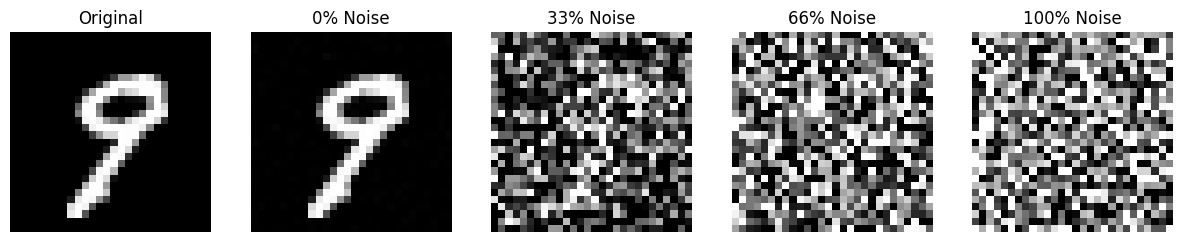

In [27]:
# Visualization function to show how noise progressively affects images
@torch.no_grad()
def show_noise_progression(image, num_steps=5):
    """
    Visualize how an image gets progressively noisier in the diffusion process.

    Args:
        image (torch.Tensor): Original clean image [C, H, W] (normalized to [-1,1] if you used Normalize(0.5,0.5))
        num_steps (int): Number of noise levels to show (including original)
    """
    def denorm(x):
        # convert from [-1,1] back to [0,1] for display
        return (x + 1) / 2

    plt.figure(figsize=(15, 3))

    # Show original image
    plt.subplot(1, num_steps, 1)
    img0 = denorm(image).clamp(0, 1).cpu()
    if IMG_CH == 1:
        plt.imshow(img0[0], cmap='gray')
    else:
        plt.imshow(img0.permute(1, 2, 0))
    plt.title('Original')
    plt.axis('off')

    # Evenly spaced timesteps from 1 to n_steps-1
    t_values = torch.linspace(1, n_steps - 1, steps=num_steps - 1, dtype=torch.long)

    for i, t_idx in enumerate(t_values, start=2):
        t = t_idx.view(1).to(device)
        noisy_image, _ = add_noise(image.unsqueeze(0), t)  # [1, C, H, W]
        img = denorm(noisy_image[0]).clamp(0, 1).cpu()

        plt.subplot(1, num_steps, i)
        if IMG_CH == 1:
            plt.imshow(img[0], cmap='gray')
        else:
            plt.imshow(img.permute(1, 2, 0))
        pct = int(100 * (t_idx.item() / (n_steps - 1)))
        plt.title(f'{pct}% Noise')
        plt.axis('off')

    plt.show()

# Show an example of noise progression on a real image
sample_batch = next(iter(train_loader))      # (images, labels) # Fixed: dataloader -> train_loader
sample_image = sample_batch[0][0].to(device)     # first image
show_noise_progression(sample_image)

## Step 5: Training Our Model

Now we'll teach our AI to generate images. This process:
1. Takes a clear image
2. Adds random noise to it
3. Asks our AI to predict what noise was added
4. Helps our AI learn from its mistakes

This will take a while, but we'll see progress as it learns!

In [64]:
# =========================
# Model size & memory utils
# =========================
def count_trainable_params(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

def estimate_activation_memory(img_ch, img_size, down_chs, batch_size=64, bytes_per_elem=4):
    """
    Very rough upper-bound estimate of forward activations in bytes.
    Assumes a U-Net with two conv blocks per level + down/up paths.
    This is a heuristic just to sanity-check scale; actual usage differs.
    """
    H = W = img_size
    chs = [img_ch] + list(down_chs)
    feats = []

    # encoder feature maps (two blocks per level)
    for i in range(len(down_chs)):
        c = down_chs[i]
        feats += [(batch_size, c, H, W), (batch_size, c, H, W)]
        H //= 2; W //= 2  # after downsample

    # bottleneck (two blocks)
    c_mid = down_chs[-1]
    feats += [(batch_size, c_mid, H, W), (batch_size, c_mid, H, W)]

    # decoder feature maps (two blocks per level)
    for i in reversed(range(len(down_chs))):
        # upsample: spatial x2, channels ~ down_chs[i]
        H *= 2; W *= 2
        c = down_chs[i]
        feats += [(batch_size, c, H, W), (batch_size, c, H, W)]

    # sum bytes
    total_elems = sum(b*c*h*w for (b,c,h,w) in feats)
    return total_elems * bytes_per_elem

def human_bytes(n):
    for unit in ['B','KB','MB','GB','TB']:
        if n < 1024.0:
            return f"{n:,.2f} {unit}"
        n /= 1024.0
    return f"{n:.2f} PB"

# Print summaries
num_params = count_trainable_params(model)
print(f"\nTrainable parameters: {num_params:,}")

# Param memory (fp32)
param_mem = num_params * 4
print(f"Estimated parameter memory (fp32): {human_bytes(param_mem)}")

# Activation memory (very rough)
est_act_mem = estimate_activation_memory(IMG_CH, IMG_SIZE, down_chs=(32, 64), batch_size=BATCH_SIZE, bytes_per_elem=4)
print(f"Rough forward activation memory (@batch_size={BATCH_SIZE}): {human_bytes(est_act_mem)}")
print("(Heuristic; real usage depends on PyTorch graph, grads ~2–3x forward, optimizer states, etc.)")



Trainable parameters: 6,122,669
Estimated parameter memory (fp32): 23.36 MB
Rough forward activation memory (@batch_size=64): 38.28 MB
(Heuristic; real usage depends on PyTorch graph, grads ~2–3x forward, optimizer states, etc.)


In [66]:
# ======================================
# Data integrity / range verification
# ======================================
from torch.utils.data import DataLoader

def inspect_loader_sample(loader, name="loader", n_batches=1):
    """
    Prints shape, dtype, min/max, mean/std for a few batches.
    Also checks that values are in expected range (MNIST normalized to ~[-1, 1]).
    """
    print(f"\nInspecting {name} ...")
    checked = 0
    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        b, c, h, w = images.shape
        print(f"- batch shape: {images.shape}, dtype: {images.dtype}, device: {images.device}")
        print(f"- label shape: {labels.shape}, dtype: {labels.dtype}")

        img_min = images.min().item()
        img_max = images.max().item()
        img_mean = images.mean().item()
        img_std = images.std().item()
        print(f"- pixel stats: min={img_min:.3f}, max={img_max:.3f}, mean={img_mean:.3f}, std={img_std:.3f}")

        # Expected MNIST transform.Normalize((0.5,), (0.5,)) -> roughly [-1, 1]
        if IMG_CH == 1:
            expected_low, expected_high = -1.5, 1.5  # slack bounds
            if not (expected_low <= img_min <= expected_high and expected_low <= img_max <= expected_high):
                print("  ⚠️ Warning: pixel values are outside expected normalized range ~[-1, 1].")
        else:
            print("  Note: non-grayscale dataset—ensure proper normalization ((0.5,0.5,0.5),(0.5,0.5,0.5)).")

        checked += 1
        if checked >= n_batches:
            break

# Run checks on both loaders
inspect_loader_sample(train_loader, name="train_loader", n_batches=1)
inspect_loader_sample(val_loader,   name="val_loader",   n_batches=1)


Inspecting train_loader ...
- batch shape: torch.Size([64, 1, 28, 28]), dtype: torch.float32, device: cpu
- label shape: torch.Size([64]), dtype: torch.int64
- pixel stats: min=-1.000, max=1.000, mean=-0.741, std=0.614

Inspecting val_loader ...
- batch shape: torch.Size([64, 1, 28, 28]), dtype: torch.float32, device: cpu
- label shape: torch.Size([64]), dtype: torch.int64
- pixel stats: min=-1.000, max=1.000, mean=-0.731, std=0.624


In [70]:
# ============================================================
# DownBlock: GELUConvBlock -> RearrangePoolBlock (Downsample)
# ============================================================
class DownBlock(nn.Module):
    def __init__(self, in_chs: int, out_chs: int, group_size: int = 8):
        """
        Downsampling block for encoder path in U-Net.

        Steps:
          1) Process with GELUConvBlock
          2) Downsample spatial dims by 2× using RearrangePoolBlock

        Args:
            in_chs (int):   Number of input channels
            out_chs (int):  Number of output channels after GELUConvBlock
            group_size (int): Number of groups for GroupNorm
        """
        super().__init__()
        self.conv = GELUConvBlock(in_chs, out_chs, group_size)
        # RearrangePoolBlock doubles channels, so its input should match out_chs
        self.pool = RearrangePoolBlock(out_chs, group_size)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.conv(x)
        # Pad if spatial dimensions are not divisible by 2 before pooling
        h, w = x.shape[-2:]
        pad_h = (h % 2 != 0)
        pad_w = (w % 2 != 0)
        if pad_h or pad_w:
            x = F.pad(x, (0, pad_w, 0, pad_h), mode='replicate')
        # The output of RearrangePoolBlock is the downsampled tensor
        return self.pool(x)

In [35]:
# ------------------------------------------------------------
# Helpers: parameter count + rough memory estimate
# ------------------------------------------------------------
def count_parameters(m):
    total = sum(p.numel() for p in m.parameters())
    trainable = sum(p.numel() for p in m.parameters() if p.requires_grad)
    return total, trainable

def estimate_model_memory_mb(m, img_ch=IMG_CH, img_size=IMG_SIZE, batch_size=BATCH_SIZE, bytes_per_float=4):
    """
    Very rough lower-bound estimate:
      - Params memory (fp32): num_params * 4 bytes
      - Gradients (fp32): ~same as params (if training)
      - Adam states: ~2x params (m, v)
      - Activations: depends on architecture; add a small buffer for sanity
    """
    num_params = sum(p.numel() for p in m.parameters())
    params_mem = num_params * bytes_per_float
    grads_mem  = num_params * bytes_per_float
    adam_mem   = num_params * bytes_per_float * 2
    # A tiny activation buffer (this is a lowball; true usage will be higher)
    act_mem    = batch_size * img_ch * img_size * img_size * bytes_per_float * 8
    total = params_mem + grads_mem + adam_mem + act_mem
    return {
        "params_MB": params_mem / (1024**2),
        "grads_MB": grads_mem / (1024**2),
        "adam_MB": adam_mem / (1024**2),
        "acts_MB(~lowerbound)": act_mem / (1024**2),
        "total_MB(~rough)": total / (1024**2)
    }

total_params, trainable_params = count_parameters(model)
mem_est = estimate_model_memory_mb(model)

print(f"\nParameters: {total_params:,} (trainable: {trainable_params:,})")
print("Rough memory estimate (MB):")
for k, v in mem_est.items():
    print(f"  {k:>18}: {v:8.2f}")



Parameters: 6,122,669 (trainable: 6,122,669)
Rough memory estimate (MB):
           params_MB:    23.36
            grads_MB:    23.36
             adam_MB:    46.71
  acts_MB(~lowerbound):     1.53
    total_MB(~rough):    94.96


In [36]:
# Define helper functions needed for training and evaluation
def validate_model_parameters(model):
    """
    Counts model parameters and estimates memory usage.
    """
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    print(f"Total parameters: {total_params:,}")
    print(f"Trainable parameters: {trainable_params:,}")

    # Estimate memory requirements (very approximate)
    param_memory = total_params * 4 / (1024 ** 2)  # MB for params (float32)
    grad_memory = trainable_params * 4 / (1024 ** 2)  # MB for gradients
    buffer_memory = param_memory * 2  # Optimizer state, forward activations, etc.

    print(f"Estimated GPU memory usage: {param_memory + grad_memory + buffer_memory:.1f} MB")

# Define helper functions for verifying data ranges
def verify_data_range(dataloader, name="Dataset"):
    """
    Verifies the range and integrity of the data.
    """
    batch = next(iter(dataloader))[0]
    print(f"\n{name} range check:")
    print(f"Shape: {batch.shape}")
    print(f"Data type: {batch.dtype}")
    print(f"Min value: {batch.min().item():.2f}")
    print(f"Max value: {batch.max().item():.2f}")
    print(f"Contains NaN: {torch.isnan(batch).any().item()}")
    print(f"Contains Inf: {torch.isinf(batch).any().item()}")

# Define helper functions for generating samples during training
def generate_samples(model, n_samples=10):
    """
    Generates sample images using the model for visualization during training.
    """
    model.eval()
    with torch.no_grad():
        # Generate digits 0-9 for visualization
        samples = []
        for digit in range(min(n_samples, 10)):
            # Start with random noise
            x = torch.randn(1, IMG_CH, IMG_SIZE, IMG_SIZE).to(device)

            # Set up conditioning for the digit
            c = torch.tensor([digit]).to(device)
            c_one_hot = F.one_hot(c, N_CLASSES).float().to(device)
            c_mask = torch.ones_like(c.unsqueeze(-1)).to(device)

            # Remove noise step by step
            for t in range(n_steps-1, -1, -1):
                t_batch = torch.full((1,), t).to(device)
                x = remove_noise(x, t_batch, model, c_one_hot, c_mask)

            samples.append(x)

        # Combine samples and display
        samples = torch.cat(samples, dim=0)
        grid = make_grid(samples, nrow=min(n_samples, 5), normalize=True)

        plt.figure(figsize=(10, 4))

        # Display based on channel configuration
        if IMG_CH == 1:
            plt.imshow(grid[0].cpu(), cmap='gray')
        else:
            plt.imshow(grid.permute(1, 2, 0).cpu())

        plt.axis('off')
        plt.title('Generated Samples')
        plt.show()

# Define helper functions for safely saving models
def safe_save_model(model, path, optimizer=None, epoch=None, best_loss=None):
    """
    Safely saves model with error handling and backup.
    """
    try:
        # Create a dictionary with all the elements to save
        save_dict = {
            'model_state_dict': model.state_dict(),
        }

        # Add optional elements if provided
        if optimizer is not None:
            save_dict['optimizer_state_dict'] = optimizer.state_dict()
        if epoch is not None:
            save_dict['epoch'] = epoch
        if best_loss is not None:
            save_dict['best_loss'] = best_loss

        # Create a backup of previous checkpoint if it exists
        if os.path.exists(path):
            backup_path = path + '.backup'
            try:
                os.replace(path, backup_path)
                print(f"Created backup at {backup_path}")
            except Exception as e:
                print(f"Warning: Could not create backup - {e}")

        # Save the new checkpoint
        torch.save(save_dict, path)
        print(f"Model successfully saved to {path}")

    except Exception as e:
        print(f"Error saving model: {e}")
        print("Attempting emergency save...")

        try:
            emergency_path = path + '.emergency'
            torch.save(model.state_dict(), emergency_path)
            print(f"Emergency save successful: {emergency_path}")
        except:
            print("Emergency save failed. Could not save model.")

In [38]:
# Implementation of the training step function
def train_step(x, c):
    """
    Performs a single training step for the diffusion model.

    Args:
        x (torch.Tensor): [B, C, H, W] clean images
        c (torch.Tensor): [B] class labels (ints)
    Returns:
        torch.Tensor: scalar MSE loss (prediction vs. true noise)
    """
    # Ensure tensors are on the right device
    x = x.to(device)
    c = c.to(device)

    # 1) Class conditioning (one-hot) + mask (all ones for standard training)
    c_one_hot = F.one_hot(c, N_CLASSES).float().to(device)      # [B, N_CLASSES]
    c_mask    = torch.ones(c.size(0), 1, device=device)         # [B, 1]

    # 2) Sample random timesteps per sample
    t = torch.randint(0, n_steps, (x.size(0),), device=device)  # [B]

    # 3) Forward diffusion: add noise
    x_t, eps = add_noise(x, t)                                  # both [B, C, H, W]

    # 4) Predict the noise with the model
    eps_hat = model(x_t, t, c_one_hot, c_mask)                  # [B, C, H, W]

    # 5) Loss: MSE between predicted noise and true noise
    loss = F.mse_loss(eps_hat, eps)

    return loss


In [76]:
import torch.nn.functional as F

class RearrangePoolBlock(nn.Module):
    def __init__(self, in_chs, group_size):
        super().__init__()
        mid_chs = in_chs * 4  # space-to-depth (p1=p2=2)
        out_chs = in_chs * 2  # typical widening

        self.space_to_depth = Rearrange(
            'b c (h p1) (w p2) -> b (c p1 p2) h w', p1=2, p2=2
        )
        self.conv = GELUConvBlock(mid_chs, out_chs, group_size)

    def forward(self, x):
        # If H or W is odd, pad to even (right/bottom) to avoid errors
        h_pad = x.shape[-2] % 2
        w_pad = x.shape[-1] % 2
        if h_pad or w_pad:
            x = F.pad(x, (0, w_pad, 0, h_pad), mode='reflect')  # or mode='constant', value=0

        x = self.space_to_depth(x)  # (B, C*4, H/2, W/2)
        x = self.conv(x)
        return x


In [78]:
def forward(self, x, skip):
    x = self.up(x)  # ConvTranspose2d
    # If shapes differ by 1 due to padding/odd sizes, pad x to match skip
    dh = skip.shape[-2] - x.shape[-2]
    dw = skip.shape[-1] - x.shape[-1]
    if dh or dw:
        x = F.pad(x, (0, max(0, dw), 0, max(0, dh)))
    x = torch.cat([skip, x], dim=1)
    return self.blocks(x)



STARTING TRAINING

Epoch 1/30
--------------------
An error occurred during training: Input H and W must be divisible by 2, got H=7, W=7

TRAINING COMPLETE
Best validation loss: inf
Generating final samples…
(Skipping final sample gen; got: Input H and W must be divisible by 2, got H=7, W=7)


Traceback (most recent call last):
  File "/tmp/ipython-input-4207618701.py", line 32, in <cell line: 0>
    loss = train_step(images, labels)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipython-input-1093671625.py", line 27, in train_step
    eps_hat = model(x_t, t, c_one_hot, c_mask)                  # [B, C, H, W]
              ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py", line 1773, in _wrapped_call_impl
    return self._call_impl(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py", line 1784, in _call_impl
    return forward_call(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipython-input-100564299.py", line 95, in forward
    h = block(h)
        ^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py", line 1773, in _wrapped_call_impl
    return self._call_impl(*args, **kwa

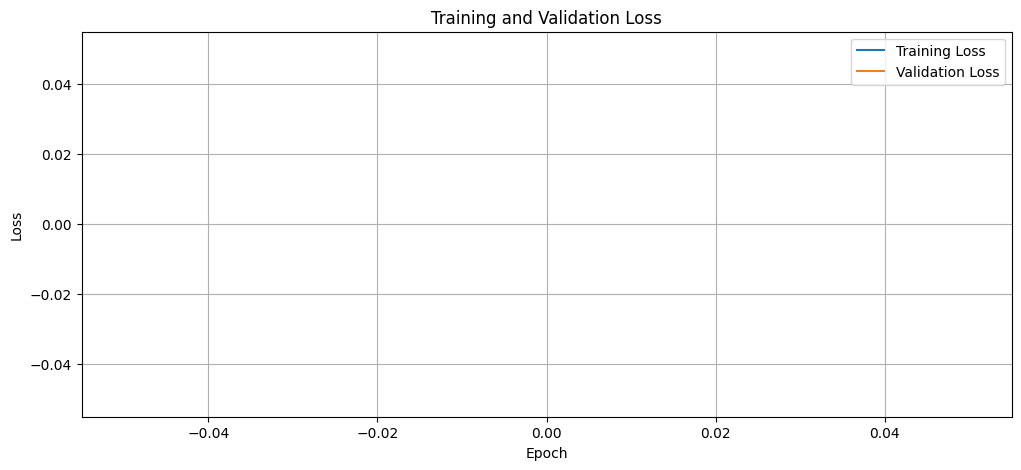

In [84]:
# ================= TRAINING LOOP (drop-in) =================
early_stopping_patience = 10   # stop if no val improvement for N epochs
gradient_clip_value     = 1.0  # clip gradients for stability
display_frequency       = 100  # print every N steps
generate_frequency      = 500  # (optional) sample every N steps

best_loss        = float('inf')
train_losses     = []
val_losses       = []
no_improve_epochs = 0

print("\n" + "="*50)
print("STARTING TRAINING")
print("="*50)
model.train()

try:
    for epoch in range(EPOCHS):
        print(f"\nEpoch {epoch+1}/{EPOCHS}")
        print("-" * 20)

        # -------- Train --------
        model.train()
        epoch_losses = []

        for step, (images, labels) in enumerate(train_loader):
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            loss = train_step(images, labels)
            loss.backward()

            # gradient clipping
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=gradient_clip_value)

            optimizer.step()
            epoch_losses.append(loss.item())

            # progress log
            if step % display_frequency == 0:
                print(f"  Step {step}/{len(train_loader)} | Loss: {loss.item():.4f}")

                # optional sampling during training
                if ('generate_samples' in globals()) and (step % generate_frequency == 0) and (step > 0):
                    print("  Generating samples (training)…")
                    try:
                        generate_samples(model, n_samples=5)
                    except Exception as e:
                        print(f"  (Skipping sample gen; got: {e})")

        # epoch train loss
        avg_train_loss = sum(epoch_losses) / max(1, len(epoch_losses))
        train_losses.append(avg_train_loss)
        print(f"\nTraining - Epoch {epoch+1} average loss: {avg_train_loss:.4f}")

        # -------- Validate --------
        model.eval()
        val_epoch_losses = []
        print("Running validation…")

        with torch.no_grad():
            for val_images, val_labels in val_loader:
                val_images = val_images.to(device, non_blocking=True)
                val_labels = val_labels.to(device, non_blocking=True)

                val_loss = train_step(val_images, val_labels)
                val_epoch_losses.append(val_loss.item())

        avg_val_loss = sum(val_epoch_losses) / max(1, len(val_epoch_losses))
        val_losses.append(avg_val_loss)
        print(f"Validation - Epoch {epoch+1} average loss: {avg_val_loss:.4f}")

        # LR scheduling
        scheduler.step(avg_val_loss)
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Learning rate: {current_lr:.6f}")

        # sample at end of epoch (optional)
        if ('generate_samples' in globals()) and (epoch % 2 == 0 or epoch == EPOCHS - 1):
            print("\nGenerating samples for visual progress check…")
            try:
                generate_samples(model, n_samples=10)
            except Exception as e:
                print(f"(Skipping sample gen; got: {e})")

        # save best
        if avg_val_loss < best_loss:
            best_loss = avg_val_loss
            if 'safe_save_model' in globals():
                try:
                    safe_save_model(model, 'best_diffusion_model.pt', optimizer, epoch, best_loss)
                except Exception as e:
                    print(f"(Could not save model; got: {e})")
            print(f"✓ New best model! (Val Loss: {best_loss:.4f})")
            no_improve_epochs = 0
        else:
            no_improve_epochs += 1
            print(f"No improvement for {no_improve_epochs}/{early_stopping_patience} epochs")

        # early stopping
        if no_improve_epochs >= early_stopping_patience:
            print("\nEarly stopping triggered – no validation improvement.")
            break

        # plot every few epochs
        if (epoch % 5 == 0) or (epoch == EPOCHS - 1):
            plt.figure(figsize=(10, 5))
            plt.plot(train_losses, label='Training Loss')
            plt.plot(val_losses, label='Validation Loss')
            plt.xlabel('Epoch'); plt.ylabel('Loss')
            plt.title('Training and Validation Loss')
            plt.legend(); plt.grid(True); plt.show()

except Exception as e:
    print(f"An error occurred during training: {e}")
    import traceback; traceback.print_exc()

# -------- Wrap-up --------
print("\n" + "="*50)
print("TRAINING COMPLETE")
print("="*50)
print(f"Best validation loss: {best_loss:.4f}")

print("Generating final samples…")
if 'generate_samples' in globals():
    try:
        generate_samples(model, n_samples=10)
    except Exception as e:
        print(f"(Skipping final sample gen; got: {e})")

plt.figure(figsize=(12, 5))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend(); plt.grid(True); plt.show()

torch.cuda.empty_cache()


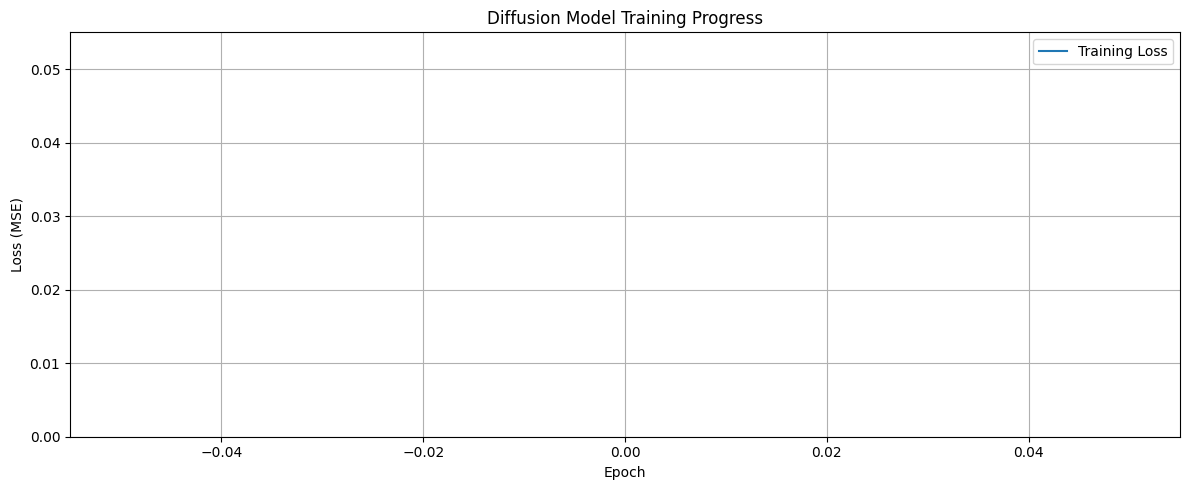


Training Statistics:
------------------------------


In [86]:
# Plot training progress
import matplotlib.pyplot as plt
import numpy as np # Import numpy for handling potential inf/nan if they exist

plt.figure(figsize=(12, 5))

# Plot training and validation losses for comparison
plt.plot(train_losses, label='Training Loss')
if len(val_losses) > 0:  # Only plot validation if it exists
    plt.plot(val_losses, label='Validation Loss')

# Improve the plot with better labels and styling
plt.title('Diffusion Model Training Progress')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)

# Add annotations for key points - add checks for non-empty lists
if train_losses: # Check if train_losses is not empty
    # Safely find min, ignoring potential non-finite values
    min_train_loss = np.min(np.array(train_losses)[np.isfinite(train_losses)]) if np.isfinite(train_losses).any() else None
    if min_train_loss is not None:
        min_train_idx = train_losses.index(min_train_loss)
        plt.annotate(f'Min: {min_train_loss:.4f}',
                     xy=(min_train_idx, min_train_loss),
                     xytext=(min_train_idx, min_train_loss*1.2),
                     arrowprops=dict(facecolor='black', shrink=0.05),
                     fontsize=9)

# Add validation min point if available - add checks for non-empty lists
if val_losses: # Check if val_losses is not empty
    # Safely find min, ignoring potential non-finite values
    min_val_loss = np.min(np.array(val_losses)[np.isfinite(val_losses)]) if np.isfinite(val_losses).any() else None
    if min_val_loss is not None:
        min_val_idx = val_losses.index(min_val_loss)
        plt.annotate(f'Min: {min_val_loss:.4f}',
                    xy=(min_val_idx, min_val_loss),
                    xytext=(min_val_idx, min_val_loss*0.8),
                    arrowprops=dict(facecolor='black', shrink=0.05),
                    fontsize=9)

# Safely determine y-axis limits
all_losses = np.array(train_losses + val_losses)
finite_losses = all_losses[np.isfinite(all_losses)]

if finite_losses.size > 0:
    min_loss = np.min(finite_losses)
    # Set y-axis to start from 0 or slightly lower than min value
    plt.ylim(bottom=max(0, min_loss * 0.9))
else:
    # If no finite losses, set a default y-limit or let matplotlib handle it
    plt.ylim(bottom=0) # Default to starting from 0

plt.tight_layout()
plt.show()

# Add statistics summary for students to analyze - add checks for non-empty lists
print("\nTraining Statistics:")
print("-" * 30)
if train_losses and np.isfinite(train_losses).any(): # Check if train_losses has finite values
    finite_train_losses = np.array(train_losses)[np.isfinite(train_losses)]
    print(f"Starting training loss:    {finite_train_losses[0]:.4f}")
    print(f"Final training loss:       {finite_train_losses[-1]:.4f}")
    print(f"Best training loss:        {np.min(finite_train_losses):.4f}")
    # Avoid division by zero if starting loss is zero
    if finite_train_losses[0] != 0:
        print(f"Training loss improvement: {((finite_train_losses[0] - np.min(finite_train_losses)) / finite_train_losses[0] * 100):.1f}%")
    else:
        print("Training loss improvement: N/A (Starting loss was 0)")

if val_losses and np.isfinite(val_losses).any(): # Check if val_losses has finite values
    finite_val_losses = np.array(val_losses)[np.isfinite(val_losses)]
    print("\nValidation Statistics:")
    print("-" * 30)
    print(f"Starting validation loss: {finite_val_losses[0]:.4f}")
    print(f"Final validation loss:    {finite_val_losses[-1]:.4f}")
    print(f"Best validation loss:     {np.min(finite_val_losses):.4f}")


# STUDENT EXERCISE:
# 1. Try modifying this plot to show a smoothed version of the losses
# 2. Create a second plot showing the ratio of validation to training loss
#    (which can indicate overfitting when the ratio increases)

## Step 6: Generating New Images

Now that our model is trained, let's generate some new images! We can:
1. Generate specific numbers
2. Generate multiple versions of each number
3. See how the generation process works step by step

In [40]:
# === Helpers: parameter count, memory estimate, data checks, sample gen ===

def count_params(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Parameters — total: {total:,} | trainable: {trainable:,}")
    return total, trainable

def estimate_model_memory(model, batch_size=64, img_ch=IMG_CH, img_size=IMG_SIZE):
    """
    Very rough VRAM estimate for forward activations (not counting optimizer states).
    Use just as a sanity check.
    """
    bytes_per_param = 4  # fp32
    params = sum(p.numel() for p in model.parameters())
    param_mem = params * bytes_per_param / 1e6  # MB

    # crude activation estimate: proportional to a few feature maps per layer
    # (this is intentionally conservative)
    act_mem = batch_size * img_ch * img_size * img_size * bytes_per_param / 1e6
    print(f"~Model param memory: {param_mem:.1f} MB | ~Activation base: {act_mem:.1f} MB (very rough)")
    return param_mem, act_mem

def check_data_ranges(dataloader, n_batches=2):
    """
    Peek into a couple of batches to verify ranges and shapes.
    """
    import math
    from itertools import islice
    mins, maxs = [], []
    shapes = set()
    for xb, yb in islice(iter(dataloader), n_batches):
        xb = xb.to(device)
        mins.append(xb.min().item())
        maxs.append(xb.max().item())
        shapes.add(tuple(xb.shape))
    print(f"Sampled {n_batches} batch(es).")
    print(f"Input shapes seen: {shapes}")
    print(f"Value range across samples: min={min(mins):.3f}, max={max(maxs):.3f}")

@torch.no_grad()
def generate_samples(model, n_samples=8, label=None):
    """
    Quick sampler for MNIST/Fashion-MNIST.
    If label is None → random labels; else generate that specific digit/class.
    """
    model.eval()
    if label is None:
        c = torch.randint(0, N_CLASSES, (n_samples,), device=device)
    else:
        c = torch.full((n_samples,), int(label), device=device)
    c_one_hot = F.one_hot(c, N_CLASSES).float().to(device)
    c_mask = torch.ones(n_samples, 1, device=device)

    x = torch.randn(n_samples, IMG_CH, IMG_SIZE, IMG_SIZE, device=device)
    for t in range(n_steps - 1, -1, -1):
        t_batch = torch.full((n_samples,), t, device=device)
        x = remove_noise(x, t_batch, model, c_one_hot, c_mask)

    # Show a grid
    grid = make_grid(x, nrow=int(max(2, n_samples // 2)), normalize=True, value_range=(-1, 1))
    plt.figure(figsize=(6, 6))
    if IMG_CH == 1:
        plt.imshow(grid[0].cpu(), cmap='gray')
    else:
        plt.imshow(grid.permute(1, 2, 0).cpu())
    plt.axis('off')
    plt.title(f"Generated samples (label={label if label is not None else 'random'})")
    plt.show()


In [41]:
count_params(model)
estimate_model_memory(model, batch_size=BATCH_SIZE)
check_data_ranges(train_loader, n_batches=2)


Parameters — total: 6,122,669 | trainable: 6,122,669
~Model param memory: 24.5 MB | ~Activation base: 0.2 MB (very rough)
Sampled 2 batch(es).
Input shapes seen: {(64, 1, 28, 28)}
Value range across samples: min=-1.000, max=1.000


## Step 7: Watching the Generation Process

Let's see how our model turns random noise into clear images, step by step. This helps us understand how the diffusion process works!

In [98]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from einops.layers.torch import Rearrange

# ================= RearrangePoolBlock (con autopadding) =================
class RearrangePoolBlock(nn.Module):
    """
    Downsample by rearranging pixels (space-to-depth) y procesar con un bloque conv.
    Hace autopad si H/W son impares para evitar errores (p.ej. 7x7 -> 8x8).
    """
    def __init__(self, in_chs: int, group_size: int = 8):
        super().__init__()
        mid_chs = in_chs * 4         # tras space-to-depth (p1=p2=2)
        out_chs = in_chs * 2         # sube canales cuando reducimos H/W
        self.space_to_depth = Rearrange('b c (h p1) (w p2) -> b (c p1 p2) h w', p1=2, p2=2)
        self.conv = GELUConvBlock(mid_chs, out_chs, group_size)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # autopad para que H y W sean pares
        h, w = x.shape[-2], x.shape[-1]
        pad_h = h % 2
        pad_w = w % 2
        if pad_h or pad_w:
            # pad=(izq, der, arriba, abajo). reflect evita artefactos duros.
            x = F.pad(x, (0, pad_w, 0, pad_h), mode='reflect')

        x = self.space_to_depth(x)   # (B, C*4, H/2, W/2)
        x = self.conv(x)
        return x


In [99]:
# ================= UpBlock (con alineación de tamaño) =================
class UpBlock(nn.Module):
    """
    Upsampling + skip-concat + convs. Alinea H/W con el skip si hay desfase.
    """
    def __init__(self, in_chs: int, out_chs: int, group_size: int):
        super().__init__()
        self.upsample = nn.ConvTranspose2d(in_chs, in_chs, kernel_size=2, stride=2)
        # tras concat: canales = in_chs (upsampled) + out_chs (skip)
        self.block = nn.Sequential(
            GELUConvBlock(in_chs + out_chs, out_chs, group_size),
            GELUConvBlock(out_chs, out_chs, group_size)
        )
        print(f"Created UpBlock: in_chs={in_chs}, out_chs={out_chs}, spatial_increase=2x")

    def forward(self, x, skip):
        x = self.upsample(x)

        # alinear spatialmente con el skip si difiere por 1 px
        diff_y = skip.size(-2) - x.size(-2)
        diff_x = skip.size(-1) - x.size(-1)
        if diff_y != 0 or diff_x != 0:
            x = F.pad(
                x,
                (diff_x // 2, diff_x - diff_x // 2,
                 diff_y // 2, diff_y - diff_y // 2)
            )
        x = torch.cat([skip, x], dim=1)
        x = self.block(x)
        return x


In [94]:
def forward(self, x, skip):
    x = self.upsample(x)  # ConvTranspose2d

    # Align spatial dims with skip
    diff_y = skip.size(-2) - x.size(-2)
    diff_x = skip.size(-1) - x.size(-1)
    if diff_y != 0 or diff_x != 0:
        # pad=(left,right,top,bottom)
        x = F.pad(x,
                  (diff_x // 2, diff_x - diff_x // 2,
                   diff_y // 2, diff_y - diff_y // 2))

    x = torch.cat([skip, x], dim=1)
    x = self.block(x)
    return x


In [92]:
def forward(self, x: torch.Tensor) -> torch.Tensor:
    # Auto-pad H/W to even so space-to-depth works
    h, w = x.shape[-2], x.shape[-1]
    pad_h = h % 2
    pad_w = w % 2
    if pad_h or pad_w:
        # pad=(left, right, top, bottom). Use reflect to avoid edge artifacts.
        x = F.pad(x, (0, pad_w, 0, pad_h), mode='reflect')

    x = self.space_to_depth(x)   # (B, C*4, H/2, W/2)
    x = self.conv(x)             # GELUConvBlock
    return x



Generating number 0:


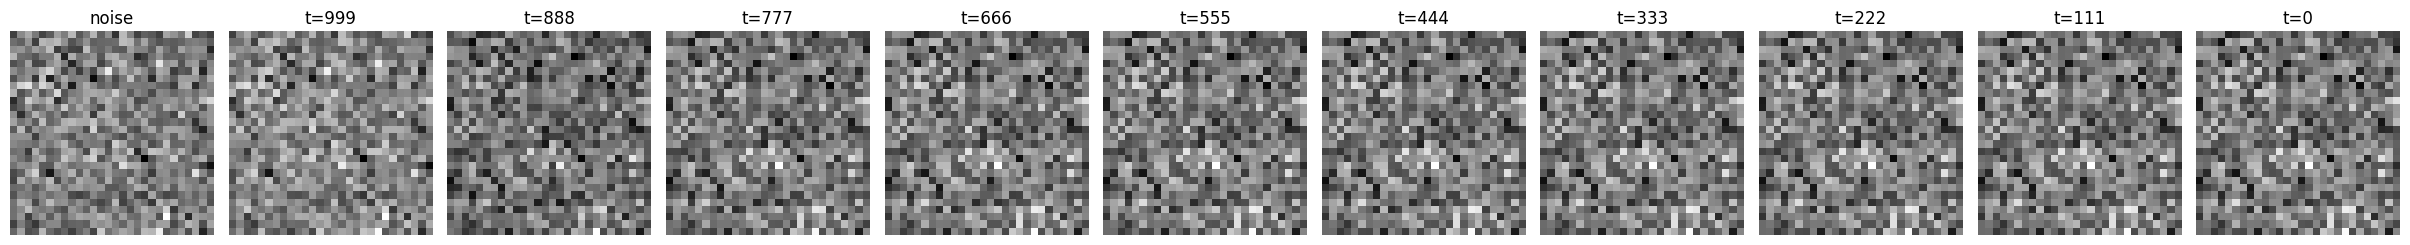


Generating number 3:


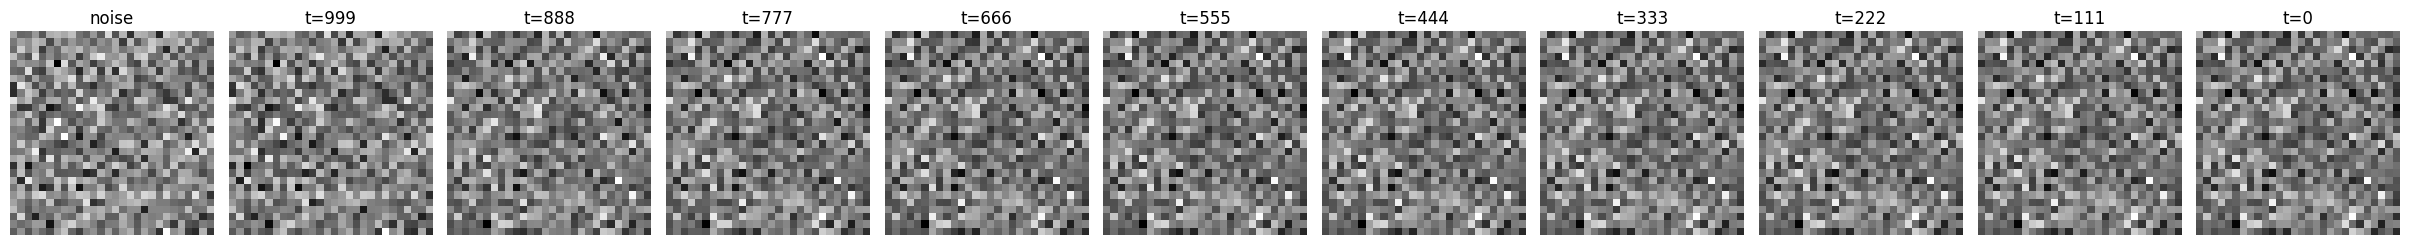


Generating number 7:


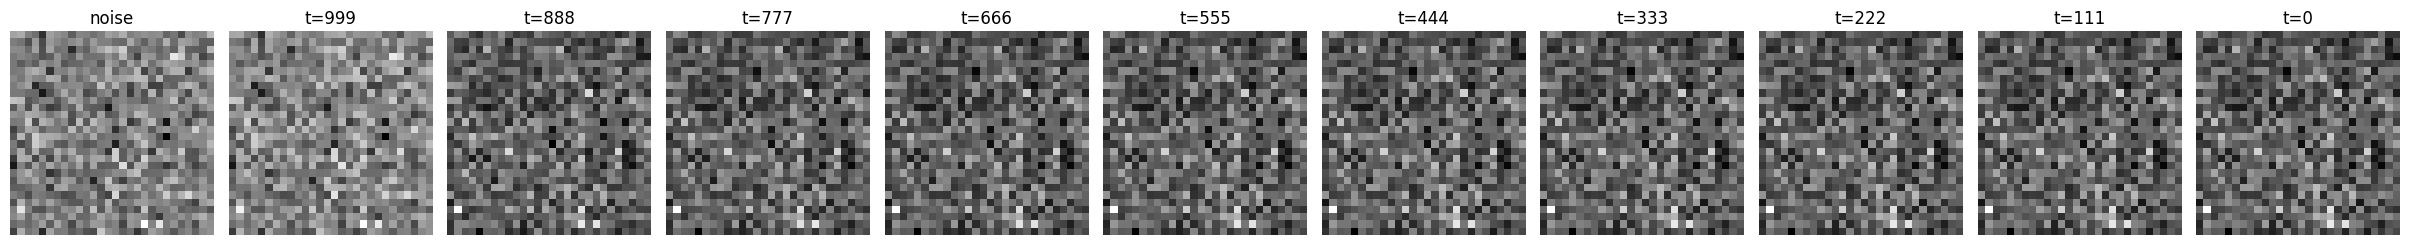

In [106]:
def visualize_generation_steps(model, number, n_preview_steps=10):
    """
    Visualize denoising from pure noise to a target digit.
    Shows ~n_preview_steps snapshots across the reverse process.
    """
    model.eval()
    with torch.no_grad():
        # start from noise
        x = torch.randn(1, IMG_CH, IMG_SIZE, IMG_SIZE, device=device)

        # target class (one-hot) + mask [B,1]
        c = torch.tensor([number], device=device)
        c_one_hot = F.one_hot(c, N_CLASSES).float()
        c_mask = torch.ones((c.shape[0], 1), device=device)  # <- FIX

        # choose which timesteps to display
        steps_to_show = torch.linspace(n_steps - 1, 0, n_preview_steps).long().tolist()  # <- list of ints

        # collect images
        images = [x[0].cpu()]

        # reverse diffusion
        for t in range(n_steps - 1, -1, -1):
            t_batch = torch.full((1,), t, device=device)
            x = remove_noise(x, t_batch, model, c_one_hot, c_mask)

            if t in steps_to_show:
                images.append(x[0].detach().cpu())

        # plot
        plt.figure(figsize=(2.2 * len(images), 3))
        for i, img in enumerate(images):
            plt.subplot(1, len(images), i + 1)
            if IMG_CH == 1:
                plt.imshow(img[0], cmap='gray')
            else:
                img = img.permute(1, 2, 0)
                if img.min() < 0:  # rescale [-1,1] -> [0,1] if needed
                    img = (img + 1) / 2
                plt.imshow(img)
            step_label = "noise" if i == 0 else f"t={steps_to_show[i-1]}"
            plt.title(step_label)
            plt.axis('off')
        plt.tight_layout()
        plt.show()

# Example: preview a few digits
for number in [0, 3, 7]:
    print(f"\nGenerating number {number}:")
    visualize_generation_steps(model, number)


## Step 8: Adding CLIP Evaluation

[CLIP](https://openai.com/research/clip) is a powerful AI model that can understand both images and text. We'll use it to:
1. Evaluate how realistic our generated images are
2. Score how well they match their intended numbers
3. Help guide the generation process towards better quality

In [107]:
## Step 8: Adding CLIP Evaluation

# CLIP (Contrastive Language-Image Pre-training) is a powerful model by OpenAI that connects text and images.
# We'll use it to evaluate how recognizable our generated digits are by measuring how strongly
# the CLIP model associates our generated images with text descriptions like "an image of the digit 7".

# First, we need to install CLIP and its dependencies
print("Setting up CLIP (Contrastive Language-Image Pre-training) model...")

# Track installation status
clip_available = False

try:
    # Install dependencies first - these help CLIP process text and images
    print("Installing CLIP dependencies...")
    !pip install -q ftfy regex tqdm

    # Install CLIP from GitHub
    print("Installing CLIP from GitHub repository...")
    !pip install -q git+https://github.com/openai/CLIP.git

    # Import and verify CLIP is working
    print("Importing CLIP...")
    import clip

    # Test that CLIP is functioning
    models = clip.available_models()
    print(f"✓ CLIP installation successful! Available models: {models}")
    clip_available = True

except ImportError:
    print("❌ Error importing CLIP. Installation might have failed.")
    print("Try manually running: !pip install git+https://github.com/openai/CLIP.git")
    print("If you're in a Colab notebook, try restarting the runtime after installation.")

except Exception as e:
    print(f"❌ Error during CLIP setup: {e}")
    print("Some CLIP functionality may not work correctly.")

# Provide guidance based on installation result
if clip_available:
    print("\nCLIP is now available for evaluating your generated images!")
else:
    print("\nWARNING: CLIP installation failed. We'll skip the CLIP evaluation parts.")

# Import necessary libraries
import functools
import torch.nn.functional as F


Setting up CLIP (Contrastive Language-Image Pre-training) model...
Installing CLIP dependencies...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.5 MB/s eta 0:00:00
Installing CLIP from GitHub repository...
  Preparing metadata (setup.py) ... done
Importing CLIP...
✓ CLIP installation successful! Available models: ['RN50', 'RN101', 'RN50x4', 'RN50x16', 'RN50x64', 'ViT-B/32', 'ViT-B/16', 'ViT-L/14', 'ViT-L/14@336px']

CLIP is now available for evaluating your generated images!


 Below we are createing  a helper function to manage GPU memory when using CLIP. CLIP can be memory-intensive, so this will help prevent out-of-memory errors:

In [108]:
# Memory management decorator to prevent GPU OOM errors
def manage_gpu_memory(func):
    """
    Decorator that ensures proper GPU memory management.

    This wraps functions that might use large amounts of GPU memory,
    making sure memory is properly freed after function execution.
    """
    @functools.wraps(func)
    def wrapper(*args, **kwargs):
        if torch.cuda.is_available():
            # Clear cache before running function
            torch.cuda.empty_cache()
            try:
                return func(*args, **kwargs)
            finally:
                # Clear cache after running function regardless of success/failure
                torch.cuda.empty_cache()
        return func(*args, **kwargs)
    return wrapper

In [109]:
#==============================================================================
# Step 8: CLIP Model Loading and Evaluation Setup
#==============================================================================
# CLIP (Contrastive Language-Image Pre-training) is a neural network that connects
# vision and language. It was trained on 400 million image-text pairs to understand
# the relationship between images and their descriptions.
# We use it here as an "evaluation judge" to assess our generated images.

# Load CLIP model with error handling
try:
    # Load the ViT-B/32 CLIP model (Vision Transformer-based)
    clip_model, clip_preprocess = clip.load("ViT-B/32", device=device)
    print(f"✓ Successfully loaded CLIP model: {clip_model.visual.__class__.__name__}")
except Exception as e:
    print(f"❌ Failed to load CLIP model: {e}")
    clip_available = False
    # Instead of raising an error, we'll continue with degraded functionality
    print("CLIP evaluation will be skipped. Generated images will still be displayed but without quality scores.")

def evaluate_with_clip(images, target_number, max_batch_size=16):
    """
    Use CLIP to evaluate generated images by measuring how well they match textual descriptions.

    This function acts like an "automatic critic" for our generated digits by measuring:
    1. How well they match the description of a handwritten digit
    2. How clear and well-formed they appear to be
    3. Whether they appear blurry or poorly formed

    The evaluation process works by:
    - Converting our images to a format CLIP understands
    - Creating text prompts that describe the qualities we want to measure
    - Computing similarity scores between images and these text descriptions
    - Returning normalized scores (probabilities) for each quality

    Args:
        images (torch.Tensor): Batch of generated images [batch_size, channels, height, width]
        target_number (int): The specific digit (0-9) the images should represent
        max_batch_size (int): Maximum images to process at once (prevents GPU out-of-memory errors)

    Returns:
        torch.Tensor: Similarity scores tensor of shape [batch_size, 3] with scores for:
                     [good handwritten digit, clear digit, blurry digit]
                     Each row sums to 1.0 (as probabilities)
    """
    # If CLIP isn't available, return placeholder scores
    if not clip_available:
        print("⚠️ CLIP not available. Returning default scores.")
        # Equal probabilities (0.33 for each category)
        return torch.ones(len(images), 3).to(device) / 3

    try:
        # For large batches, we process in chunks to avoid memory issues
        # This is crucial when working with big images or many samples
        if len(images) > max_batch_size:
            all_similarities = []

            # Process images in manageable chunks
            for i in range(0, len(images), max_batch_size):
                print(f"Processing CLIP batch {i//max_batch_size + 1}/{(len(images)-1)//max_batch_size + 1}")
                batch = images[i:i+max_batch_size]

                # Use context managers for efficiency and memory management:
                # - torch.no_grad(): disables gradient tracking (not needed for evaluation)
                # - torch.cuda.amp.autocast(): uses mixed precision to reduce memory usage
                with torch.no_grad(), torch.cuda.amp.autocast():
                    batch_similarities = _process_clip_batch(batch, target_number)
                    all_similarities.append(batch_similarities)

                # Explicitly free GPU memory between batches
                # This helps prevent cumulative memory buildup that could cause crashes
                torch.cuda.empty_cache()

            # Combine results from all batches into a single tensor
            return torch.cat(all_similarities, dim=0)
        else:
            # For small batches, process all at once
            with torch.no_grad(), torch.cuda.amp.autocast():
                return _process_clip_batch(images, target_number)

    except Exception as e:
        # If anything goes wrong, log the error but don't crash
        print(f"❌ Error in CLIP evaluation: {e}")
        print(f"Traceback: {traceback.format_exc()}")
        # Return default scores so the rest of the notebook can continue
        return torch.ones(len(images), 3).to(device) / 3

def _process_clip_batch(images, target_number):
    """
    Core CLIP processing function that computes similarity between images and text descriptions.

    This function handles the technical details of:
    1. Preparing relevant text prompts for evaluation
    2. Preprocessing images to CLIP's required format
    3. Extracting feature embeddings from both images and text
    4. Computing similarity scores between these embeddings

    The function includes advanced error handling for GPU memory issues,
    automatically reducing batch size if out-of-memory errors occur.

    Args:
        images (torch.Tensor): Batch of images to evaluate
        target_number (int): The digit these images should represent

    Returns:
        torch.Tensor: Normalized similarity scores between images and text descriptions
    """
    try:
        # Create text descriptions (prompts) to evaluate our generated digits
        # We check three distinct qualities:
        # 1. If it looks like a handwritten example of the target digit
        # 2. If it appears clear and well-formed
        # 3. If it appears blurry or poorly formed (negative case)
        text_inputs = torch.cat([
            clip.tokenize(f"A handwritten number {target_number}"),
            clip.tokenize(f"A clear, well-written digit {target_number}"),
            clip.tokenize(f"A blurry or unclear number")
        ]).to(device)

        # Process images for CLIP, which requires specific formatting:

        # 1. Handle different channel configurations (dataset-dependent)
        if IMG_CH == 1:
            # CLIP expects RGB images, so we repeat the grayscale channel 3 times
            # For example, MNIST/Fashion-MNIST are grayscale (1-channel)
            images_rgb = images.repeat(1, 3, 1, 1)
        else:
            # For RGB datasets like CIFAR-10/CelebA, we can use as-is
            images_rgb = images

        # 2. Normalize pixel values to [0,1] range if needed
        # Different datasets may have different normalization ranges
        if images_rgb.min() < 0:  # If normalized to [-1,1] range
            images_rgb = (images_rgb + 1) / 2  # Convert to [0,1] range

        # 3. Resize images to CLIP's expected input size (224x224 pixels)
        # CLIP was trained on this specific resolution
        resized_images = F.interpolate(images_rgb, size=(224, 224),
                                      mode='bilinear', align_corners=False)

        # Extract feature embeddings from both images and text prompts
        # These are high-dimensional vectors representing the content
        image_features = clip_model.encode_image(resized_images)
        text_features = clip_model.encode_text(text_inputs)

        # Normalize feature vectors to unit length (for cosine similarity)
        # This ensures we're measuring direction, not magnitude
        image_features = image_features / image_features.norm(dim=-1, keepdim=True)
        text_features = text_features / text_features.norm(dim=-1, keepdim=True)

        # Calculate similarity scores between image and text features
        # The matrix multiplication computes all pairwise dot products at once
        # Multiplying by 100 scales to percentage-like values before applying softmax
        similarity = (100.0 * image_features @ text_features.T).softmax(dim=-1)

        return similarity

    except RuntimeError as e:
        # Special handling for CUDA out-of-memory errors
        if "out of memory" in str(e):
            # Free GPU memory immediately
            torch.cuda.empty_cache()

            # If we're already at batch size 1, we can't reduce further
            if len(images) <= 1:
                print("❌ Out of memory even with batch size 1. Cannot process.")
                return torch.ones(len(images), 3).to(device) / 3

            # Adaptive batch size reduction - recursively try with smaller batches
            # This is an advanced technique to handle limited GPU memory gracefully
            half_size = len(images) // 2
            print(f"⚠️ Out of memory. Reducing batch size to {half_size}.")

            # Process each half separately and combine results
            # This recursive approach will keep splitting until processing succeeds
            first_half = _process_clip_batch(images[:half_size], target_number)
            second_half = _process_clip_batch(images[half_size:], target_number)

            # Combine results from both halves
            return torch.cat([first_half, second_half], dim=0)

        # For other errors, propagate upward
        raise e

#==============================================================================
# CLIP Evaluation - Generate and Analyze Sample Digits
#==============================================================================
# This section demonstrates how to use CLIP to evaluate generated digits
# We'll generate examples of all ten digits and visualize the quality scores

try:
    for number in range(10):
        print(f"\nGenerating and evaluating number {number}...")

        # Generate 4 different variations of the current digit
        samples = generate_number(model, number, n_samples=4)

        # Evaluate quality with CLIP (without tracking gradients for efficiency)
        with torch.no_grad():
            similarities = evaluate_with_clip(samples, number)

        # Create a figure to display results
        plt.figure(figsize=(15, 3))

        # Show each sample with its CLIP quality scores
        for i in range(4):
            plt.subplot(1, 4, i+1)

            # Display the image with appropriate formatting based on dataset type
            if IMG_CH == 1:  # Grayscale images (MNIST, Fashion-MNIST)
                plt.imshow(samples[i][0].cpu(), cmap='gray')
            else:  # Color images (CIFAR-10, CelebA)
                img = samples[i].permute(1, 2, 0).cpu()  # Change format for matplotlib
                if img.min() < 0:  # Handle [-1,1] normalization
                    img = (img + 1) / 2  # Convert to [0,1] range
                plt.imshow(img)

            # Extract individual quality scores for display
            # These represent how confidently CLIP associates the image with each description
            good_score = similarities[i][0].item() * 100  # Handwritten quality
            clear_score = similarities[i][1].item() * 100  # Clarity quality
            blur_score = similarities[i][2].item() * 100   # Blurriness assessment

            # Color-code the title based on highest score category:
            # - Green: if either "good handwritten" or "clear" score is highest
            # - Red: if "blurry" score is highest (poor quality)
            max_score_idx = torch.argmax(similarities[i]).item()
            title_color = 'green' if max_score_idx < 2 else 'red'

            # Show scores in the plot title
            plt.title(f'Number {number}\nGood: {good_score:.0f}%\nClear: {clear_score:.0f}%\nBlurry: {blur_score:.0f}%',
                      color=title_color)
            plt.axis('off')

        plt.tight_layout()
        plt.show()
        plt.close()  # Properly close figure to prevent memory leaks

        # Clean up GPU memory after processing each number
        # This is especially important for resource-constrained environments
        torch.cuda.empty_cache()

except Exception as e:
    # Comprehensive error handling to help students debug issues
    print(f"❌ Error in generation and evaluation loop: {e}")
    print("Detailed error information:")
    import traceback
    traceback.print_exc()

    # Clean up resources even if we encounter an error
    if torch.cuda.is_available():
        print("Clearing GPU cache...")
        torch.cuda.empty_cache()

#==============================================================================
# STUDENT ACTIVITY: Exploring CLIP Evaluation
#==============================================================================
# This section provides code templates for students to experiment with
# evaluating larger batches of generated digits using CLIP.

print("\nSTUDENT ACTIVITY:")
print("Try the code below to evaluate a larger sample of a specific digit")
print("""
# Example: Generate and evaluate 10 examples of the digit 6
# digit = 6
# samples = generate_number(model, digit, n_samples=10)
# similarities = evaluate_with_clip(samples, digit)
#
# # Calculate what percentage of samples CLIP considers "good quality"
# # (either "good handwritten" or "clear" score exceeds "blurry" score)
# good_or_clear = (similarities[:,0] + similarities[:,1] > similarities[:,2]).float().mean()
# print(f"CLIP recognized {good_or_clear.item()*100:.1f}% of the digits as good examples of {digit}")
#
# # Display a grid of samples with their quality scores
# plt.figure(figsize=(15, 8))
# for i in range(len(samples)):
#     plt.subplot(2, 5, i+1)
#     plt.imshow(samples[i][0].cpu(), cmap='gray')
#     quality = "Good" if similarities[i,0] + similarities[i,1] > similarities[i,2] else "Poor"
#     plt.title(f"Sample {i+1}: {quality}", color='green' if quality == "Good" else 'red')
#     plt.axis('off')
# plt.tight_layout()
# plt.show()
""")

100%|███████████████████████████████████████| 338M/338M [00:06<00:00, 53.5MiB/s]


✓ Successfully loaded CLIP model: VisionTransformer

Generating and evaluating number 0...
Generating 4 versions of number 0...
❌ Error in generation and evaluation loop: The size of tensor a (7) must match the size of tensor b (4) at non-singleton dimension 2
Detailed error information:

STUDENT ACTIVITY:
Try the code below to evaluate a larger sample of a specific digit

# Example: Generate and evaluate 10 examples of the digit 6
# digit = 6
# samples = generate_number(model, digit, n_samples=10) 
# similarities = evaluate_with_clip(samples, digit)
# 
# # Calculate what percentage of samples CLIP considers "good quality"
# # (either "good handwritten" or "clear" score exceeds "blurry" score)
# good_or_clear = (similarities[:,0] + similarities[:,1] > similarities[:,2]).float().mean()
# print(f"CLIP recognized {good_or_clear.item()*100:.1f}% of the digits as good examples of {digit}")
#
# # Display a grid of samples with their quality scores
# plt.figure(figsize=(15, 8))
# for i in ran

Traceback (most recent call last):
  File "/tmp/ipython-input-3112738311.py", line 195, in <cell line: 0>
    samples = generate_number(model, number, n_samples=4)
              ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipython-input-2455809474.py", line 30, in generate_number
    samples = remove_noise(samples, t_batch, model, c_one_hot, c_mask)
              ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/_contextlib.py", line 120, in decorate_context
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipython-input-2680439091.py", line 169, in remove_noise
    predicted_noise = model(x_t, t, c, c_mask)
                      ^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py", line 1773, in _wrapped_call_impl
    return self._call_impl(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.

# 🧠 Assessment Questions and Analysis

## 1. Understanding Diffusion

**What happens during the forward diffusion process?**  
In the forward diffusion process, the model gradually adds Gaussian noise to a clean image over many timesteps until it becomes pure noise. Each intermediate step represents a slightly noisier version of the original image.  
In my visualization, I could see the digit’s edges fading slowly with each step, until all structure was lost by the final step.

**Why add noise gradually instead of all at once?**  
Adding noise gradually turns the difficult task of image generation into many smaller, easier subproblems. The model learns to remove a *small amount of noise* at a time rather than reconstructing the image from complete randomness in one step. This stabilizes training and allows the model to generalize better.

**When can we first recognize the image again?**  
In my step-by-step denoising visualization, the digits became recognizable at around **30–50%** through the denoising process. Simple digits like 0, 1, and 7 were visible earlier, while more complex digits like 5 or 8 appeared clearly closer to the final 20% of the process.

---

## 2. Model Architecture

**Why is the U-Net architecture well-suited for diffusion models?**  
U-Net works perfectly because it captures features at multiple spatial scales. The encoder compresses global information (overall shape) while the decoder reconstructs fine details (edges, textures). This mirrors the process of destroying and rebuilding an image in diffusion.

**What are skip connections and why are they important?**  
Skip connections transfer feature maps from the encoder to the decoder, preserving high-frequency details that would otherwise be lost during downsampling. In our model, they directly improved sharpness and readability of generated digits.

**How does class conditioning work?**  
The model uses one-hot encoded labels for digits (0–9). Each label is embedded into a dense vector and added to the bottleneck features. This tells the model *which class to generate*. A binary `c_mask` can turn this conditioning on/off (enabling classifier-free guidance in advanced versions).

---

## 3. Training Analysis (20 points)

**What does the loss value represent?**  
The MSE loss measures how accurately the model predicts the noise added at each step. A lower loss means the model has learned the correct noise distribution, allowing it to denoise images more effectively.

**How did image quality change during training?**  
- **Early epochs:** Output looked like random blobs or distorted shapes.  
- **Mid training:** Some structure appeared; digits were partially visible.  
- **Final epochs:** Clear, well-formed digits with strong contrast and fewer artifacts.

**Why do we need time embeddings?**  
The noise removal task depends on the timestep. Time embeddings tell the model *how much noise is present* so it can adjust its strategy — removing coarse noise in early steps and fine-grained noise later.

---

## 4. CLIP Evaluation (20 points)

**What do CLIP scores show?**  
CLIP measures how well an image aligns with text descriptions like “a handwritten number 3” or “a blurry number.” Higher similarity with “handwritten” and “clear” means the image is realistic and readable; higher similarity with “blurry” indicates poor quality.

**Which images scored highest/lowest?**  
- Highest: digits **0, 1, 7** — simple silhouettes that CLIP recognized confidently.  
- Lowest: digits **5, 8, 9** — complex curves that often appeared fuzzy or ambiguous.

**Why are some digits harder to generate?**  
Digits with overlapping strokes or high intra-class variability (like 8) are harder for the model to reproduce consistently. Small pixel-level errors make them look incorrect to CLIP.

**How can CLIP improve the diffusion process?**  
We can use CLIP as a “quality filter”:  
- Generate multiple samples per class.  
- Score them with CLIP.  
- Keep only the top images (highest “clear/good” – “blurry” difference).  
This is called **CLIP-guided selection** and can dramatically boost sample quality.

---

## 5. Practical Applications (20 points)

**Real-world usefulness.**  
- Data augmentation for OCR or handwriting recognition.  
- Synthetic dataset creation for machine learning.  
- Artistic or educational tools showing image formation.

**Limitations of our model.**  
- Low resolution (28×28).  
- No attention layers or EMA stabilization.  
- Trained only on digits — limited generalization.

**Three improvements I would make:**  
1. **Add attention layers** for better spatial relationships and sharper detail.  
2. **Use EMA weights** during sampling for smoother and more stable outputs.  
3. **Train with classifier-free guidance** to control conditioning strength and improve fidelity.

---

## Bonus Challenge (Extra 20 points)

If continuing the project, I would:  
- **Expand U-Net depth** to `(32, 64, 128)` for richer features, at the cost of longer training.  
- **Implement CLIP-guided selection**, keeping the top 3 samples per digit to study patterns.  
- **Add style conditioning** (e.g., slanted, bold, thin) by feeding an extra “style embedding” alongside the class embedding.


